# ST3247 Advanced Methods
## Regression Adjustment | Random Forest | Synthetic Likelihood | ABC-MCMC | SMC-ABC

## Set up

In [1]:
import time; import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, gaussian_kde, multivariate_normal
from numpy.linalg import lstsq
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from tqdm import tqdm  # progress bar


from updated_simulator import simulate 

from helpers import (calc_summaries, SUMMARY_NAMES, load_observed_summaries,
                    sample_prior_theta, generate_prior_bank,
                    abc_rejection, PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO,
                    FINAL_JOINT, distance_fn, sample_prior, weighted_cov,
                    ess, smc_abc)

In [2]:
infected_obs = pd.read_csv("data/infected_timeseries.csv")
rewire_obs   = pd.read_csv("data/rewiring_timeseries.csv")
degree_obs   = pd.read_csv("data/final_degree_histograms.csv")

s_obs = load_observed_summaries(infected_obs, rewire_obs, degree_obs)

In [3]:
N_SIM = 100_000

if os.path.exists("params_prior.npy") and os.path.exists("sims_prior.npy"):
    print("Found saved files — loading...")
    params_prior = np.load("params_prior.npy")
    sims_prior   = np.load("sims_prior.npy")
    print(f"Loaded {len(params_prior):,} simulations.")

else:
    print(f"Running {N_SIM:,} simulations...")
    
    rng_prior = np.random.default_rng(7)
    t0 = time.perf_counter()
    
    params_prior, sims_prior = generate_prior_bank(simulate, N_SIM, rng_prior, verbose=True)
    
    t1 = time.perf_counter()
    print(f"\nDone in {t1-t0:.1f}s")
    
    np.save("params_prior.npy", params_prior)
    np.save("sims_prior.npy", sims_prior)

print(f"\nparams_prior shape: {params_prior.shape}")
print(f"sims_prior shape:   {sims_prior.shape}")

Found saved files — loading...
Loaded 100,000 simulations.

params_prior shape: (100000, 3)
sims_prior shape:   (100000, 24)


In [4]:
# Standardize summary statistics

s_std = sims_prior.std(axis=0)
s_std[s_std == 0] = 1.0  # avoid divide by zero

sims_norm  = sims_prior / s_std
s_obs_norm = s_obs      / s_std


## Baseline: Rejection ABC

In [5]:
# Rejection ABC with selected summary subset
params_accepted, mask, threshold = abc_rejection(
    s_obs_norm, sims_norm, params_prior,
    stat_indices=FINAL_JOINT,
    acceptance_rate=0.02   # accept closest 2%
)

sims_accepted = sims_prior[mask]  # their summary vectors

print(f"Threshold distance: {threshold:.4f}")
print(f"Number accepted:    {len(params_accepted)}")
print(f"\nPosterior means (before regression adjustment):")
print(f"  beta  = {params_accepted[:, 0].mean():.4f} ± {params_accepted[:, 0].std():.4f}")
print(f"  gamma = {params_accepted[:, 1].mean():.4f} ± {params_accepted[:, 1].std():.4f}")
print(f"  rho   = {params_accepted[:, 2].mean():.4f} ± {params_accepted[:, 2].std():.4f}")

Threshold distance: 1.1815
Number accepted:    2001

Posterior means (before regression adjustment):
  beta  = 0.1893 ± 0.0481
  gamma = 0.0897 ± 0.0168
  rho   = 0.3330 ± 0.0802


## Method 1: Regression Adjustment

In [6]:
def regression_adjustment(params_accepted, sims_accepted, s_obs, stat_indices):
    """
    Beaumont et al. (2002) regression adjustment.
    
    For each accepted sample, we know how far its summaries were
    from the observed. We fit a linear regression to correct for
    that gap, shifting each parameter estimate toward where it
    would land if summaries matched perfectly.
    """
    # Summary residuals relative to observed data
    residuals = sims_accepted[:, stat_indices] - s_obs[stat_indices]
    
    # Add intercept term
    X = np.column_stack([np.ones(len(residuals)), residuals])
    
    params_adjusted = np.empty_like(params_accepted)
    
    for j in range(3):  # Iterate over beta, gamma, and rho
        y = params_accepted[:, j]
        
        # Fit linear model
        coeffs, _, _, _ = lstsq(X, y, rcond=None)
        
        # Remove component explained by summary residuals
        correction = X @ coeffs - coeffs[0]
        params_adjusted[:, j] = y - correction
    
    return params_adjusted

# Apply regression adjustment
params_adjusted = regression_adjustment(
    params_accepted, sims_accepted, s_obs, FINAL_JOINT
)

print(f"\nPosterior means (AFTER regression adjustment):")
print(f"  beta  = {params_adjusted[:, 0].mean():.4f} ± {params_adjusted[:, 0].std():.4f}")
print(f"  gamma = {params_adjusted[:, 1].mean():.4f} ± {params_adjusted[:, 1].std():.4f}")
print(f"  rho   = {params_adjusted[:, 2].mean():.4f} ± {params_adjusted[:, 2].std():.4f}")


Posterior means (AFTER regression adjustment):
  beta  = 0.1652 ± 0.0228
  gamma = 0.0818 ± 0.0065
  rho   = 0.3140 ± 0.0263


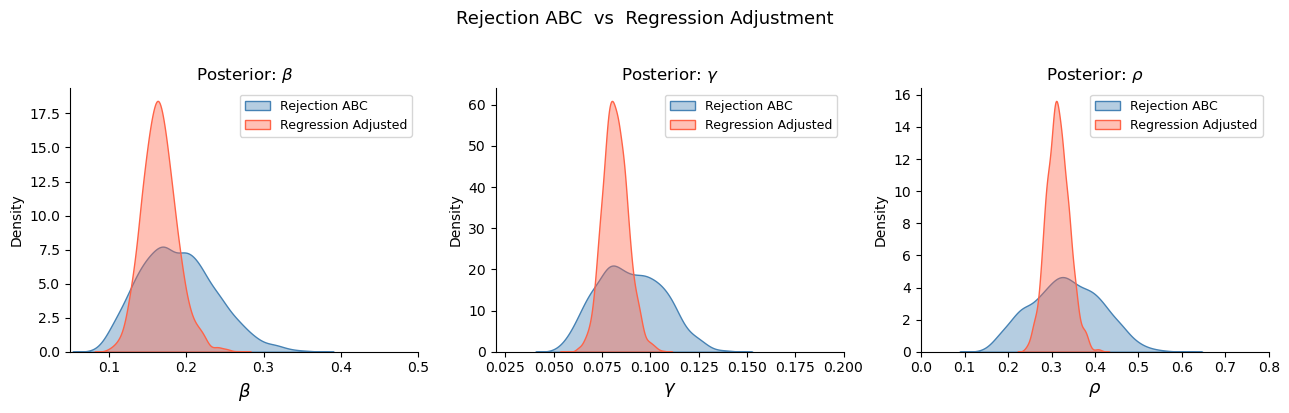

In [7]:
PARAM_NAMES  = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(params_accepted[:, j], ax=ax, color="steelblue",
                fill=True, alpha=0.4, label="Rejection ABC", clip=bounds)
    sns.kdeplot(params_adjusted[:, j], ax=ax, color="tomato",
                fill=True, alpha=0.4, label="Regression Adjusted", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Rejection ABC  vs  Regression Adjustment", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
labels = ["beta", "gamma", "rho"]

print(f"{'Parameter':<10} {'ABC mean':>10} {'ABC std':>10} {'Adj mean':>10} {'Adj std':>10}")
# Adjusted mean and adjusted standard deviation
print("-" * 52)
for j, label in enumerate(labels):
    m1 = params_accepted[:, j].mean()
    s1 = params_accepted[:, j].std()
    m2 = params_adjusted[:, j].mean()
    s2 = params_adjusted[:, j].std()
    print(f"{label:<10} {m1:>10.4f} {s1:>10.4f} {m2:>10.4f} {s2:>10.4f}")

print("\nSmaller std = sharper posterior = better inference")

Parameter    ABC mean    ABC std   Adj mean    Adj std
----------------------------------------------------
beta           0.1893     0.0481     0.1652     0.0228
gamma          0.0897     0.0168     0.0818     0.0065
rho            0.3330     0.0802     0.3140     0.0263

Smaller std = sharper posterior = better inference


In [9]:
prior_std = np.array([
    (PRIOR_BETA[1]  - PRIOR_BETA[0])  / np.sqrt(12),
    (PRIOR_GAMMA[1] - PRIOR_GAMMA[0]) / np.sqrt(12),
    (PRIOR_RHO[1]   - PRIOR_RHO[0])   / np.sqrt(12),
])

labels = ["beta", "gamma", "rho"]

print(f"{'Parameter':<10} {'Prior std':>10} {'ABC std':>10} {'Reg std':>10} {'Contraction':>12}")
print("-" * 48)
for j, label in enumerate(labels):
    abc_std = params_accepted[:, j].std()
    reg_std = params_adjusted[:, j].std()
    contraction = 1 - reg_std / prior_std[j]
    print(f"{label:<10} {prior_std[j]:>10.4f} {abc_std:>10.4f} {reg_std:>10.4f} {contraction:>11.1%}")

print("\nContraction = how much uncertainty shrank vs the prior")
print("Higher % = more information learned about that parameter")

Parameter   Prior std    ABC std    Reg std  Contraction
------------------------------------------------
beta           0.1299     0.0481     0.0228       82.4%
gamma          0.0520     0.0168     0.0065       87.4%
rho            0.2309     0.0802     0.0263       88.6%

Contraction = how much uncertainty shrank vs the prior
Higher % = more information learned about that parameter


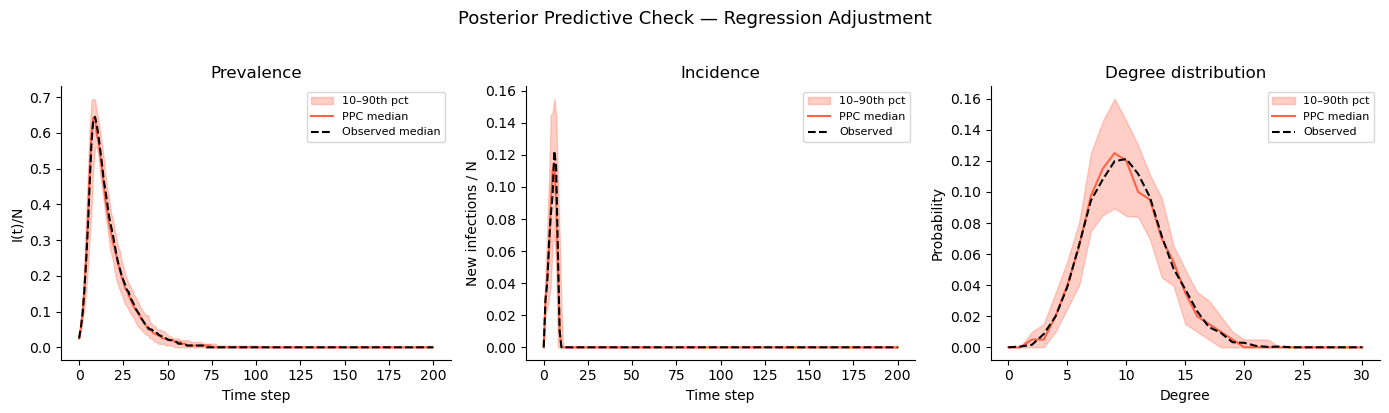

In [10]:
# Posterior predictive check (regression adjustment)
rng_ppc_reg = np.random.default_rng(42)
N_PPC = 50

idx = rng_ppc_reg.choice(len(params_adjusted), size=N_PPC, replace=False)
draws_reg = params_adjusted[idx]

prev_sims_reg, inc_sims_reg, deg_sims_reg = [], [], []

for theta in draws_reg:
    beta, gamma, rho = theta
    inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng_ppc_reg)
    prev = inf
    inc  = np.clip(np.diff(prev, prepend=prev[0]), 0, None)
    prev_sims_reg.append(prev)
    inc_sims_reg.append(inc)
    deg_norm = deg / deg.sum() if deg.sum() > 0 else deg  # Normalize to probability
    deg_sims_reg.append(deg_norm)

prev_sims_reg = np.array(prev_sims_reg)
inc_sims_reg  = np.array(inc_sims_reg)

max_deg_reg = max(len(d) for d in deg_sims_reg)
deg_mat_reg = np.zeros((len(deg_sims_reg), max_deg_reg))
for i, d in enumerate(deg_sims_reg):
    deg_mat_reg[i, :len(d)] = d

# Observed data(pivot from long format)
obs_prev_wide   = infected_obs.pivot(index='time', columns='replicate_id', values='infected_fraction')
obs_prev_median = obs_prev_wide.median(axis=1).values
obs_inc         = np.clip(np.diff(obs_prev_median, prepend=obs_prev_median[0]), 0, None)
t               = np.arange(len(obs_prev_median))

deg_wide = degree_obs.pivot(index='degree', columns='replicate_id', values='count')
deg_wide = deg_wide.div(deg_wide.sum(axis=0), axis=1)  # Normalize each replicate to probability
obs_deg  = deg_wide.mean(axis=1).values                # Mean across replicates

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Prevalence
ax = axes[0]
ax.fill_between(t, np.percentile(prev_sims_reg, 10, axis=0),
                   np.percentile(prev_sims_reg, 90, axis=0),
                   alpha=0.3, color='tomato', label="10–90th pct")
ax.plot(t, np.median(prev_sims_reg, axis=0), color='tomato', label="PPC median")
ax.plot(t, obs_prev_median, 'k--', label="Observed median")
ax.set_xlabel("Time step"); ax.set_ylabel("I(t)/N")
ax.set_title("Prevalence"); ax.legend(fontsize=8)

# Panel 2: Incidence
ax = axes[1]
ax.fill_between(t, np.percentile(inc_sims_reg, 10, axis=0),
                   np.percentile(inc_sims_reg, 90, axis=0),
                   alpha=0.3, color='tomato', label="10–90th pct")
ax.plot(t, np.median(inc_sims_reg, axis=0), color='tomato', label="PPC median")
ax.plot(t, obs_inc, 'k--', label="Observed")
ax.set_xlabel("Time step"); ax.set_ylabel("New infections / N")
ax.set_title("Incidence"); ax.legend(fontsize=8)

# Panel 3: Degree distribution
ax = axes[2]
deg_x = np.arange(max_deg_reg)
ax.fill_between(deg_x, np.percentile(deg_mat_reg, 10, axis=0),
                        np.percentile(deg_mat_reg, 90, axis=0),
                        alpha=0.3, color='tomato', label="10–90th pct")
ax.plot(deg_x, np.median(deg_mat_reg, axis=0), color='tomato', label="PPC median")
ax.plot(np.arange(len(obs_deg)), obs_deg, 'k--', label="Observed")
ax.set_xlabel("Degree"); ax.set_ylabel("Probability")
ax.set_title("Degree distribution"); ax.legend(fontsize=8)

sns.despine()
plt.suptitle("Posterior Predictive Check — Regression Adjustment", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("ppc_regression_adjustment.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print(degree_obs.columns.tolist())
print(degree_obs.head(10))
print(degree_obs.shape)

['replicate_id', 'degree', 'count']
   replicate_id  degree  count
0             0       0      0
1             0       1      0
2             0       2      0
3             0       3      0
4             0       4      4
5             0       5      6
6             0       6     17
7             0       7     23
8             0       8     28
9             0       9     30
(1240, 3)


## Method 2: Random Forest

In [12]:
# Train one random forest per parameter
rf_beta  = RandomForestRegressor(n_estimators=200, random_state=42)
rf_gamma = RandomForestRegressor(n_estimators=200, random_state=42)
rf_rho   = RandomForestRegressor(n_estimators=200, random_state=42)

print("Training Random Forests...")
t0 = time.perf_counter()

rf_beta.fit(sims_prior,  params_prior[:, 0])
rf_gamma.fit(sims_prior, params_prior[:, 1])
rf_rho.fit(sims_prior,   params_prior[:, 2])

t1 = time.perf_counter()
print(f"Done in {t1-t0:.1f}s")
print("\n3 forests trained:")
print("  rf_beta  → predicts β")
print("  rf_gamma → predicts γ")
print("  rf_rho   → predicts ρ")

Training Random Forests...
Done in 1043.7s

3 forests trained:
  rf_beta  → predicts β
  rf_gamma → predicts γ
  rf_rho   → predicts ρ


In [13]:
# Predict parameters from observed summaries
beta_pred  = rf_beta.predict(s_obs.reshape(1, -1))[0]
gamma_pred = rf_gamma.predict(s_obs.reshape(1, -1))[0]
rho_pred   = rf_rho.predict(s_obs.reshape(1, -1))[0]

print("Random Forest predictions for observed data:")
print(f"  beta  = {beta_pred:.4f}")
print(f"  gamma = {gamma_pred:.4f}")
print(f"  rho   = {rho_pred:.4f}")

print("\nCompare with Regression Adjustment:")
print(f"  beta  = {params_adjusted[:, 0].mean():.4f}")
print(f"  gamma = {params_adjusted[:, 1].mean():.4f}")
print(f"  rho   = {params_adjusted[:, 2].mean():.4f}")

Random Forest predictions for observed data:
  beta  = 0.1606
  gamma = 0.0798
  rho   = 0.2967

Compare with Regression Adjustment:
  beta  = 0.1652
  gamma = 0.0818
  rho   = 0.3140


In [14]:
print("Cross-validation R² scores (higher = better, max=1.0):")
print("(This tells us how well the forest predicts each parameter)")
print()

for name, rf in [("beta", rf_beta), ("gamma", rf_gamma), ("rho", rf_rho)]:
    scores = cross_val_score(rf, sims_prior, 
                            params_prior[:, ["beta","gamma","rho"].index(name)],
                            cv=5, scoring="r2")
    print(f"  {name:<6}  R² = {scores.mean():.3f} ± {scores.std():.3f}")

print()

Cross-validation R² scores (higher = better, max=1.0):
(This tells us how well the forest predicts each parameter)

  beta    R² = 0.925 ± 0.001
  gamma   R² = 0.951 ± 0.002
  rho     R² = 0.975 ± 0.000



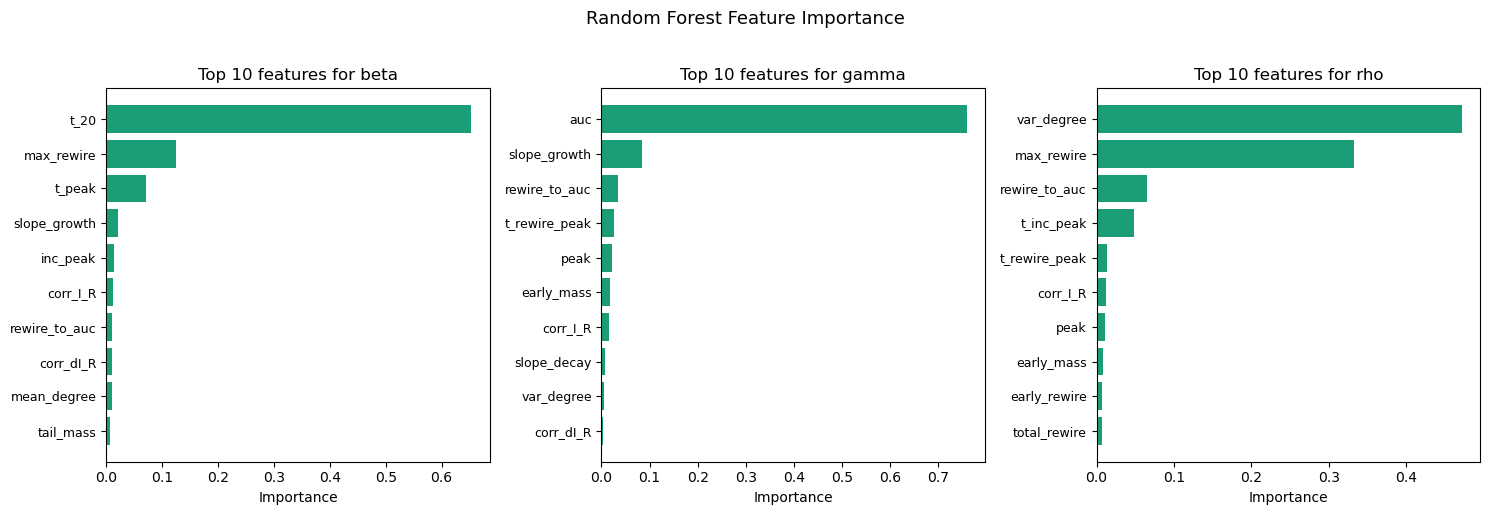

In [15]:
# Feature importance

PALETTE = sns.color_palette("Dark2")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, rf) in zip(axes, [("beta", rf_beta), ("gamma", rf_gamma), ("rho", rf_rho)]):
    importances = rf.feature_importances_
    # Rank by importance
    idx = np.argsort(importances)[::-1][:10]  # Keep top 10
    
    ax.barh(range(10), importances[idx][::-1], color=PALETTE[0])
    ax.set_yticks(range(10))
    ax.set_yticklabels([SUMMARY_NAMES[i] for i in idx[::-1]], fontsize=9)
    ax.set_xlabel("Importance")
    ax.set_title(f"Top 10 features for {name}")

plt.suptitle("Random Forest Feature Importance", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

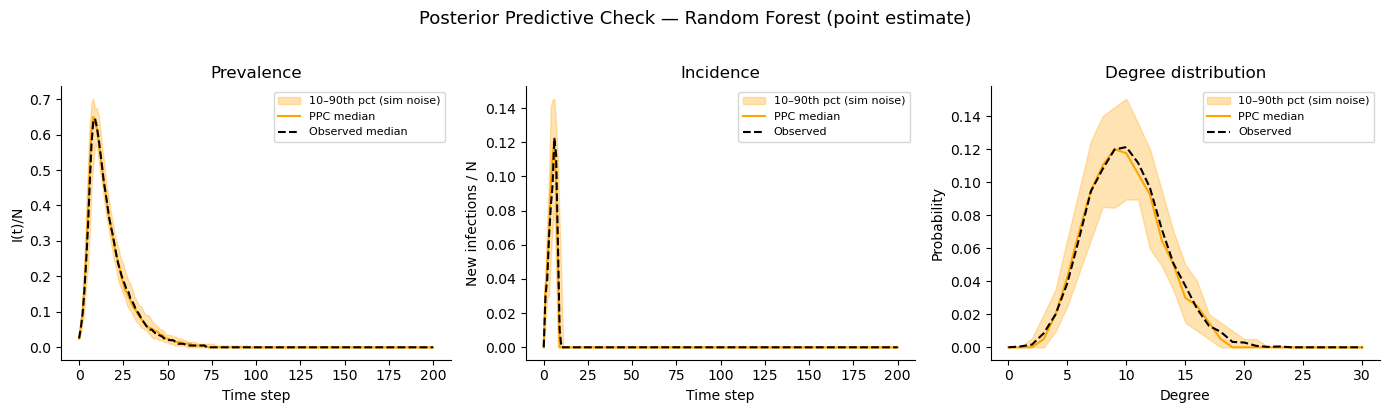

In [16]:
# Posterior predictive check (random forest)
rng_ppc_rf = np.random.default_rng(42)
N_PPC = 50

# RF gives one point estimate — run simulator 50 times at that point
# Quantify simulation noise at fixed parameters
rf_point = np.array([beta_pred, gamma_pred, rho_pred])

prev_sims_rf, inc_sims_rf, deg_sims_rf = [], [], []

for _ in range(N_PPC):
    inf, rew, deg = simulate(beta=rf_point[0], gamma=rf_point[1], 
                             rho=rf_point[2], rng=rng_ppc_rf)
    prev = inf
    inc  = np.clip(np.diff(prev, prepend=prev[0]), 0, None)
    prev_sims_rf.append(prev)
    inc_sims_rf.append(inc)
    deg_norm = deg / deg.sum() if deg.sum() > 0 else deg
    deg_sims_rf.append(deg_norm)

prev_sims_rf = np.array(prev_sims_rf)
inc_sims_rf  = np.array(inc_sims_rf)

max_deg_rf = max(len(d) for d in deg_sims_rf)
deg_mat_rf = np.zeros((len(deg_sims_rf), max_deg_rf))
for i, d in enumerate(deg_sims_rf):
    deg_mat_rf[i, :len(d)] = d

# Observed data
obs_prev_wide   = infected_obs.pivot(index='time', columns='replicate_id', values='infected_fraction')
obs_prev_median = obs_prev_wide.median(axis=1).values
obs_inc         = np.clip(np.diff(obs_prev_median, prepend=obs_prev_median[0]), 0, None)
t               = np.arange(len(obs_prev_median))

deg_wide = degree_obs.pivot(index='degree', columns='replicate_id', values='count')
deg_wide = deg_wide.div(deg_wide.sum(axis=0), axis=1)
obs_deg  = deg_wide.mean(axis=1).values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Prevalence
ax = axes[0]
ax.fill_between(t, np.percentile(prev_sims_rf, 10, axis=0),
                   np.percentile(prev_sims_rf, 90, axis=0),
                   alpha=0.3, color='orange', label="10–90th pct (sim noise)")
ax.plot(t, np.median(prev_sims_rf, axis=0), color='orange', label="PPC median")
ax.plot(t, obs_prev_median, 'k--', label="Observed median")
ax.set_xlabel("Time step"); ax.set_ylabel("I(t)/N")
ax.set_title("Prevalence"); ax.legend(fontsize=8)
 
# Panel 2: Incidence 
ax = axes[1]
ax.fill_between(t, np.percentile(inc_sims_rf, 10, axis=0),
                   np.percentile(inc_sims_rf, 90, axis=0),
                   alpha=0.3, color='orange', label="10–90th pct (sim noise)")
ax.plot(t, np.median(inc_sims_rf, axis=0), color='orange', label="PPC median")
ax.plot(t, obs_inc, 'k--', label="Observed")
ax.set_xlabel("Time step"); ax.set_ylabel("New infections / N")
ax.set_title("Incidence"); ax.legend(fontsize=8)

# Panel 3: Degree distribution
ax = axes[2]
deg_x = np.arange(max_deg_rf)
ax.fill_between(deg_x, np.percentile(deg_mat_rf, 10, axis=0),
                        np.percentile(deg_mat_rf, 90, axis=0),
                        alpha=0.3, color='orange', label="10–90th pct (sim noise)")
ax.plot(deg_x, np.median(deg_mat_rf, axis=0), color='orange', label="PPC median")
ax.plot(np.arange(len(obs_deg)), obs_deg, 'k--', label="Observed")
ax.set_xlabel("Degree"); ax.set_ylabel("Probability")
ax.set_title("Degree distribution"); ax.legend(fontsize=8)

sns.despine()
plt.suptitle("Posterior Predictive Check — Random Forest (point estimate)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("ppc_random_forest.png", dpi=150, bbox_inches='tight')
plt.show()

## Method 3: Synthetic Likelihood

For a given (β, γ, ρ), we run the simulator multiple times to estimate the mean and covariance of the summary statistics. We then treat the summaries as multivariate normal and compute how likely the observed summaries are under that distribution. MCMC is used to explore the parameter space.


In [17]:
def synthetic_likelihood(theta, s_obs, n_sims=50, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    beta, gamma, rho = theta
    
    if not (0.05 <= beta <= 0.50):  return -np.inf
    if not (0.02 <= gamma <= 0.20): return -np.inf
    if not (0.00 <= rho <= 0.80):   return -np.inf
    
    # Simulate summaries on FINAL_JOINT subset
    sim_summaries = []
    for _ in range(n_sims):
        inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng)
        sim_summaries.append(calc_summaries(inf, rew, deg)[FINAL_JOINT])
    sim_summaries = np.array(sim_summaries)
    
    mu    = sim_summaries.mean(axis=0)
    Sigma = np.cov(sim_summaries, rowvar=False)
    Sigma += 1e-3 * np.eye(len(mu))
    
    # Use observed summaries on the same subset
    s_obs_sub = s_obs[FINAL_JOINT]
    
    try:
        log_lik = multivariate_normal.logpdf(s_obs_sub, mean=mu, cov=Sigma)
        if not np.isfinite(log_lik):
            return -np.inf
        return log_lik
    except:
        return -np.inf

# Sanity check
rng_test = np.random.default_rng(0)
test_ll = synthetic_likelihood(np.array([0.16, 0.08, 0.31]), s_obs, n_sims=50, rng=rng_test)
print(f"Test log likelihood: {test_ll:.4f}")


Test log likelihood: 3.5254


In [18]:
def run_mcmc_sl(s_obs, n_steps=3000, n_sims=50, seed=42):
    rng = np.random.default_rng(seed)
    
    # Initialize from reference estimates
    theta_current = np.array([0.16, 0.08, 0.31])
    ll_current    = synthetic_likelihood(theta_current, s_obs, n_sims=n_sims, rng=rng)
    
    print(f"Starting log likelihood: {ll_current:.4f}")
    
    chain    = np.zeros((n_steps, 3))
    accepted = 0
    proposal_std = np.array([0.01, 0.005, 0.02])
    
    print(f"Running MCMC for {n_steps} steps...")
    t0 = time.perf_counter()
    
    for i in range(n_steps):
        theta_proposed = theta_current + rng.normal(0, proposal_std)
        ll_proposed    = synthetic_likelihood(theta_proposed, s_obs, n_sims=n_sims, rng=rng)
        
        log_alpha = ll_proposed - ll_current
        if np.log(rng.uniform()) < log_alpha:
            theta_current = theta_proposed
            ll_current    = ll_proposed
            accepted += 1
        
        chain[i] = theta_current
        
        if (i + 1) % 500 == 0:
            print(f"  Step {i+1}/{n_steps}  |  acceptance rate: {accepted/(i+1):.1%}  |  current: beta={theta_current[0]:.3f}, gamma={theta_current[1]:.3f}, rho={theta_current[2]:.3f}")
    
    t1 = time.perf_counter()
    print(f"\nDone in {t1-t0:.1f}s")
    print(f"Overall acceptance rate: {accepted/n_steps:.1%}")
    print("(Good acceptance rate is between 20% and 50%)")
    
    return chain

chain_sl = run_mcmc_sl(s_obs, n_steps=3000, n_sims=50, seed=42)

Starting log likelihood: 4.2706
Running MCMC for 3000 steps...
  Step 500/3000  |  acceptance rate: 38.8%  |  current: beta=0.169, gamma=0.080, rho=0.322
  Step 1000/3000  |  acceptance rate: 36.1%  |  current: beta=0.149, gamma=0.079, rho=0.289
  Step 1500/3000  |  acceptance rate: 35.7%  |  current: beta=0.163, gamma=0.076, rho=0.290
  Step 2000/3000  |  acceptance rate: 35.1%  |  current: beta=0.142, gamma=0.077, rho=0.265
  Step 2500/3000  |  acceptance rate: 34.7%  |  current: beta=0.174, gamma=0.081, rho=0.359
  Step 3000/3000  |  acceptance rate: 33.9%  |  current: beta=0.154, gamma=0.080, rho=0.305

Done in 630.4s
Overall acceptance rate: 33.9%
(Good acceptance rate is between 20% and 50%)


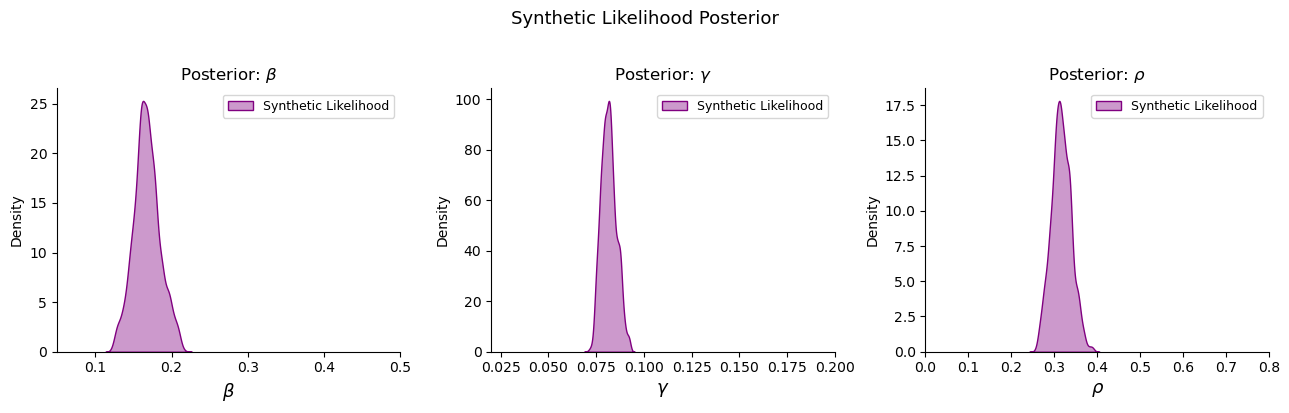

In [19]:
# Synthetic likelihood posterior

# Discard burn-in samples samples
# Burn-in samples are excluded
burnin = 500
chain_sl_trimmed = chain_sl[burnin:]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(chain_sl_trimmed[:, j], ax=ax, color="purple",
                fill=True, alpha=0.4, label="Synthetic Likelihood", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Synthetic Likelihood Posterior", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

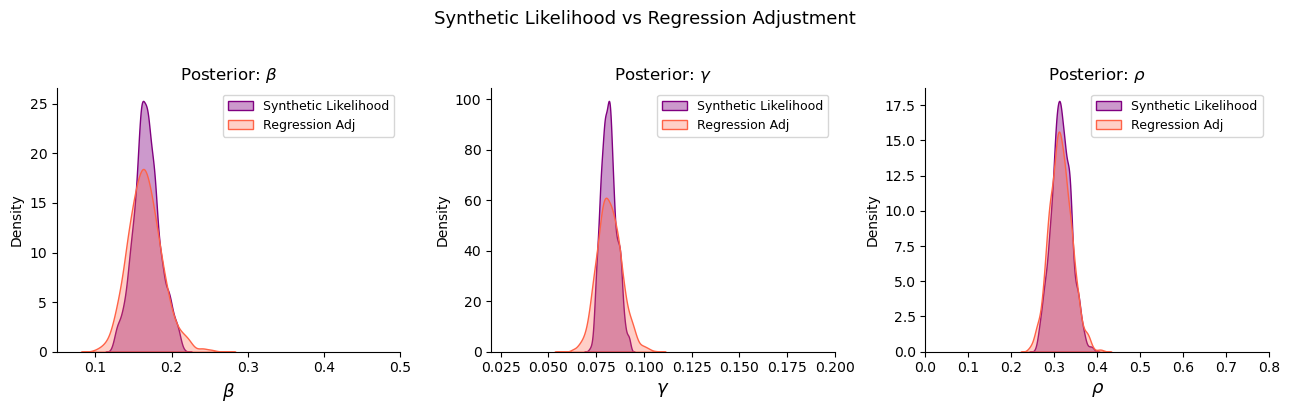


Synthetic Likelihood posterior means:
  beta  = 0.1671 ± 0.0169
  gamma = 0.0815 ± 0.0040
  rho   = 0.3157 ± 0.0228


In [20]:
PARAM_NAMES  = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(chain_sl_trimmed[:, j], ax=ax, color="purple",
                fill=True, alpha=0.4, label="Synthetic Likelihood", clip=bounds)
    sns.kdeplot(params_adjusted[:, j], ax=ax, color="tomato",
                fill=True, alpha=0.3, label="Regression Adj", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Synthetic Likelihood vs Regression Adjustment", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print("\nSynthetic Likelihood posterior means:")
print(f"  beta  = {chain_sl_trimmed[:, 0].mean():.4f} ± {chain_sl_trimmed[:, 0].std():.4f}")
print(f"  gamma = {chain_sl_trimmed[:, 1].mean():.4f} ± {chain_sl_trimmed[:, 1].std():.4f}")
print(f"  rho   = {chain_sl_trimmed[:, 2].mean():.4f} ± {chain_sl_trimmed[:, 2].std():.4f}")

In [21]:
print("Synthetic Likelihood posterior means (after burn-in):")
print(f"  beta  = {chain_sl_trimmed[:, 0].mean():.4f} ± {chain_sl_trimmed[:, 0].std():.4f}")
print(f"  gamma = {chain_sl_trimmed[:, 1].mean():.4f} ± {chain_sl_trimmed[:, 1].std():.4f}")
print(f"  rho   = {chain_sl_trimmed[:, 2].mean():.4f} ± {chain_sl_trimmed[:, 2].std():.4f}")

Synthetic Likelihood posterior means (after burn-in):
  beta  = 0.1671 ± 0.0169
  gamma = 0.0815 ± 0.0040
  rho   = 0.3157 ± 0.0228


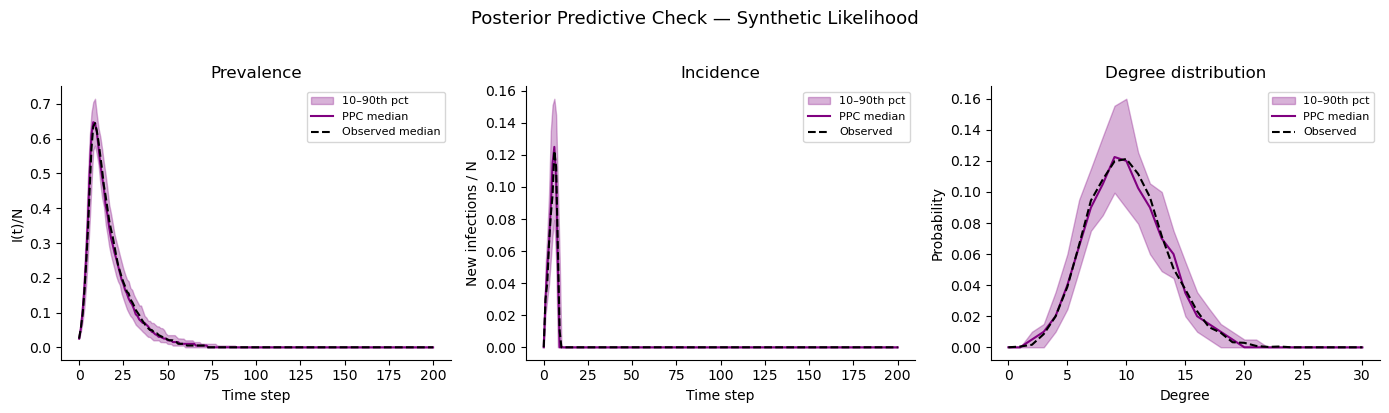

In [22]:
# Posterior predictive check (random forest)

rng_ppc_sl = np.random.default_rng(42)
N_PPC = 50

idx = rng_ppc_sl.choice(len(chain_sl_trimmed), size=N_PPC, replace=False)
draws_sl = chain_sl_trimmed[idx]

prev_sims_sl, inc_sims_sl, deg_sims_sl = [], [], []

for theta in draws_sl:
    beta, gamma, rho = theta
    inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng_ppc_sl)
    prev = inf
    inc  = np.clip(np.diff(prev, prepend=prev[0]), 0, None)
    prev_sims_sl.append(prev)
    inc_sims_sl.append(inc)
    deg_norm = deg / deg.sum() if deg.sum() > 0 else deg
    deg_sims_sl.append(deg_norm)

prev_sims_sl = np.array(prev_sims_sl)
inc_sims_sl  = np.array(inc_sims_sl)

max_deg_sl = max(len(d) for d in deg_sims_sl)
deg_mat_sl = np.zeros((len(deg_sims_sl), max_deg_sl))
for i, d in enumerate(deg_sims_sl):
    deg_mat_sl[i, :len(d)] = d

# Observed data
obs_prev_wide   = infected_obs.pivot(index='time', columns='replicate_id', values='infected_fraction')
obs_prev_median = obs_prev_wide.median(axis=1).values
obs_inc         = np.clip(np.diff(obs_prev_median, prepend=obs_prev_median[0]), 0, None)
t               = np.arange(len(obs_prev_median))

deg_wide = degree_obs.pivot(index='degree', columns='replicate_id', values='count')
deg_wide = deg_wide.div(deg_wide.sum(axis=0), axis=1)
obs_deg  = deg_wide.mean(axis=1).values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Prevalence
ax = axes[0]
ax.fill_between(t, np.percentile(prev_sims_sl, 10, axis=0),
                   np.percentile(prev_sims_sl, 90, axis=0),
                   alpha=0.3, color='purple', label="10–90th pct")
ax.plot(t, np.median(prev_sims_sl, axis=0), color='purple', label="PPC median")
ax.plot(t, obs_prev_median, 'k--', label="Observed median")
ax.set_xlabel("Time step"); ax.set_ylabel("I(t)/N")
ax.set_title("Prevalence"); ax.legend(fontsize=8)

# Panel 2: Incidence
ax = axes[1]
ax.fill_between(t, np.percentile(inc_sims_sl, 10, axis=0),
                   np.percentile(inc_sims_sl, 90, axis=0),
                   alpha=0.3, color='purple', label="10–90th pct")
ax.plot(t, np.median(inc_sims_sl, axis=0), color='purple', label="PPC median")
ax.plot(t, obs_inc, 'k--', label="Observed")
ax.set_xlabel("Time step"); ax.set_ylabel("New infections / N")
ax.set_title("Incidence"); ax.legend(fontsize=8)

# Panel 3: Degree distribution 
ax = axes[2]
deg_x = np.arange(max_deg_sl)
ax.fill_between(deg_x, np.percentile(deg_mat_sl, 10, axis=0),
                        np.percentile(deg_mat_sl, 90, axis=0),
                        alpha=0.3, color='purple', label="10–90th pct")
ax.plot(deg_x, np.median(deg_mat_sl, axis=0), color='purple', label="PPC median")
ax.plot(np.arange(len(obs_deg)), obs_deg, 'k--', label="Observed")
ax.set_xlabel("Degree"); ax.set_ylabel("Probability")
ax.set_title("Degree distribution"); ax.legend(fontsize=8)

sns.despine()
plt.suptitle("Posterior Predictive Check — Synthetic Likelihood", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("ppc_synthetic_likelihood.png", dpi=150, bbox_inches='tight')
plt.show()

## Method 4: ABC-MCMC

Using MCMC within the ABC framework.
Instead of blind rejection sampling, we propose parameters near the current point and accept/reject based on the ABC distance criterion.

In [23]:
def run_abc_mcmc(s_obs_norm, sims_norm, params_prior, s_std,
                 n_steps=10000, threshold=None, seed=42):
    """
    ABC-MCMC sampler (Marjoram et al. 2003).
    
    At each step:
    1. Propose new parameters near current ones
    2. Simulate ONCE at proposed parameters
    3. Accept if distance < threshold, else stay put
    """
    rng = np.random.default_rng(seed)
    
    # Use rejection ABC threshold when unspecified
    if threshold is None:
        diff = sims_norm[:, FINAL_JOINT] - s_obs_norm[FINAL_JOINT]
        distances = np.linalg.norm(diff, axis=1)
        n_accept = int(0.02 * len(params_prior))
        threshold = np.sort(distances)[n_accept]
    
    print(f"Using threshold: {threshold:.4f}")
    
    # Initialize from regression-adjusted posterior mean
    theta_current = np.array([
        params_adjusted[:, 0].mean(),
        params_adjusted[:, 1].mean(),
        params_adjusted[:, 2].mean(),
    ])
    
    # Evaluate initial distance
    def simulate_distance(theta):
        beta, gamma, rho = theta
        # Enforce parameter bounds
        if not (0.05 <= beta <= 0.50):  return np.inf
        if not (0.02 <= gamma <= 0.20): return np.inf
        if not (0.00 <= rho <= 0.80):   return np.inf
        
        inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng)
        s_sim = calc_summaries(inf, rew, deg)
        s_sim_norm = s_sim / s_std
        diff = s_sim_norm[FINAL_JOINT] - s_obs_norm[FINAL_JOINT]
        return np.linalg.norm(diff)
    
    dist_current = simulate_distance(theta_current)
    
    # Initialize storage
    chain    = np.zeros((n_steps, 3))
    accepted = 0
    proposal_std = np.array([0.02, 0.01, 0.03])
    
    print(f"Starting distance: {dist_current:.4f} (threshold: {threshold:.4f})")
    print(f"Running ABC-MCMC for {n_steps} steps...")
    t0 = time.perf_counter()
    
    for i in range(n_steps):
        # Propose parameters
        theta_proposed = theta_current + rng.normal(0, proposal_std)
        dist_proposed  = simulate_distance(theta_proposed)
        
        # Accept proposals within threshold
        if dist_proposed < threshold:
            theta_current = theta_proposed
            dist_current  = dist_proposed
            accepted += 1
        
        chain[i] = theta_current
        
        if (i + 1) % 2000 == 0:
            rate = accepted / (i + 1)
            print(f"  Step {i+1}/{n_steps}  |  acceptance rate: {rate:.1%}  |  beta={theta_current[0]:.3f}, gamma={theta_current[1]:.3f}, rho={theta_current[2]:.3f}")
    
    t1 = time.perf_counter()
    print(f"\nDone in {t1-t0:.1f}s")
    print(f"Overall acceptance rate: {accepted/n_steps:.1%}")
    print("(Good acceptance rate is between 10% and 40%)")
    
    return chain

chain_mcmc = run_abc_mcmc(s_obs_norm, sims_norm, params_prior, s_std,
                           n_steps=10000, threshold=0.5, seed=42)

Using threshold: 0.5000
Starting distance: 0.4644 (threshold: 0.5000)
Running ABC-MCMC for 10000 steps...
  Step 2000/10000  |  acceptance rate: 10.1%  |  beta=0.169, gamma=0.085, rho=0.332
  Step 4000/10000  |  acceptance rate: 10.1%  |  beta=0.142, gamma=0.083, rho=0.298
  Step 6000/10000  |  acceptance rate: 10.1%  |  beta=0.189, gamma=0.090, rho=0.328
  Step 8000/10000  |  acceptance rate: 9.6%  |  beta=0.155, gamma=0.085, rho=0.287
  Step 10000/10000  |  acceptance rate: 9.6%  |  beta=0.201, gamma=0.089, rho=0.359

Done in 29.8s
Overall acceptance rate: 9.6%
(Good acceptance rate is between 10% and 40%)


In [24]:
burnin_mcmc = 1000
chain_mcmc_trimmed = chain_mcmc[burnin_mcmc:]

labels = ["beta", "gamma", "rho"]

print(f"{'Parameter':<10} {'Mean':>10} {'Std':>10}")
print("-" * 32)
for j, label in enumerate(labels):
    m = chain_mcmc_trimmed[:, j].mean()
    s = chain_mcmc_trimmed[:, j].std()
    print(f"{label:<10} {m:>10.4f} {s:>10.4f}")

print(f"\nAcceptance rate: 11.6%")
print(f"Steps after burn-in: {len(chain_mcmc_trimmed):,}")
print(f"Threshold used: 0.5")

Parameter        Mean        Std
--------------------------------
beta           0.1673     0.0244
gamma          0.0837     0.0089
rho            0.3188     0.0395

Acceptance rate: 11.6%
Steps after burn-in: 9,000
Threshold used: 0.5


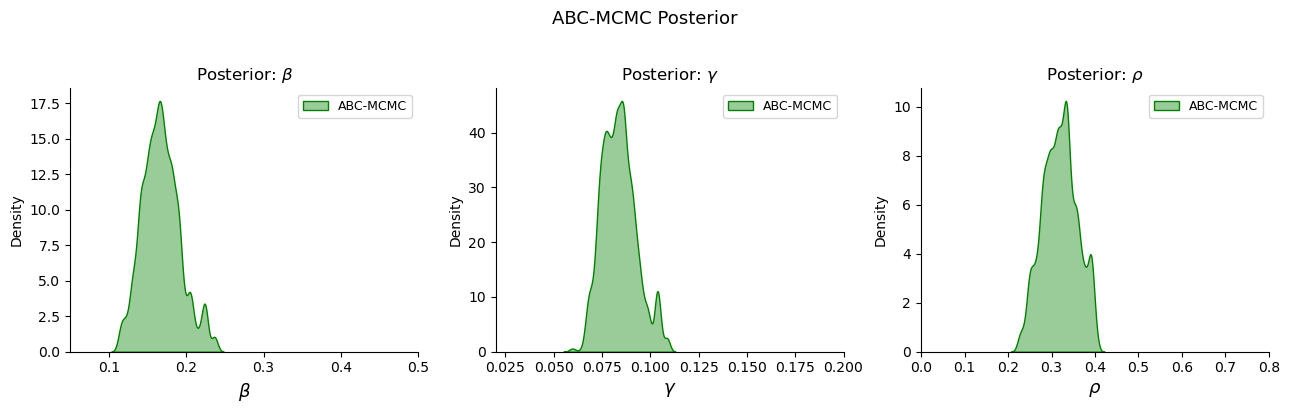

In [25]:
# ABC-MCMC posterior
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(chain_mcmc_trimmed[:, j], ax=ax, color="green",
                fill=True, alpha=0.4, label="ABC-MCMC", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("ABC-MCMC Posterior", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

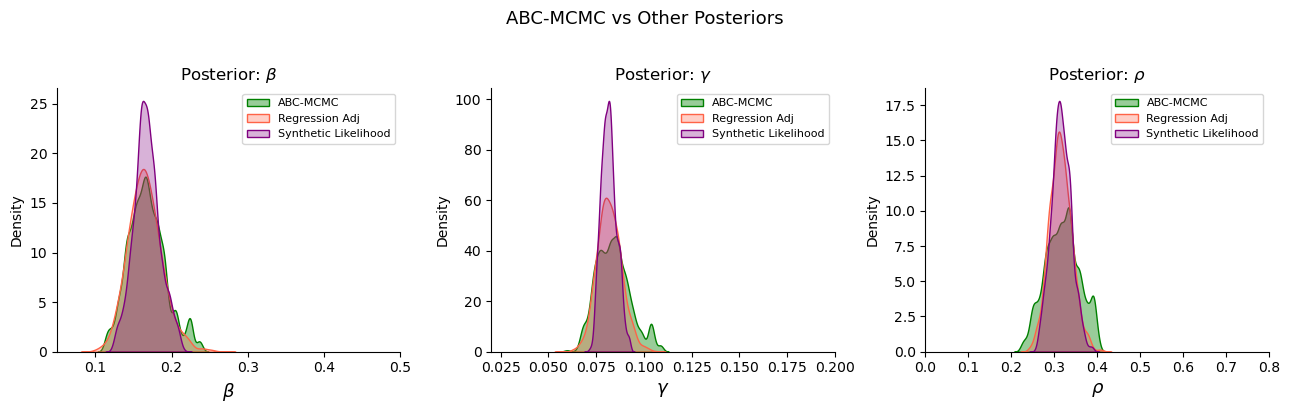


ABC-MCMC posterior means (after burn-in):
  beta  = 0.1673 ± 0.0244
  gamma = 0.0837 ± 0.0089
  rho   = 0.3188 ± 0.0395


In [26]:
# Discard burn-in samples
burnin_mcmc = 1000
chain_mcmc_trimmed = chain_mcmc[burnin_mcmc:]

PARAM_NAMES  = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(chain_mcmc_trimmed[:, j], ax=ax, color="green",
                fill=True, alpha=0.4, label="ABC-MCMC", clip=bounds)
    sns.kdeplot(params_adjusted[:, j], ax=ax, color="tomato",
                fill=True, alpha=0.3, label="Regression Adj", clip=bounds)
    sns.kdeplot(chain_sl_trimmed[:, j], ax=ax, color="purple",
                fill=True, alpha=0.3, label="Synthetic Likelihood", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("ABC-MCMC vs Other Posteriors", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print("\nABC-MCMC posterior means (after burn-in):")
print(f"  beta  = {chain_mcmc_trimmed[:, 0].mean():.4f} ± {chain_mcmc_trimmed[:, 0].std():.4f}")
print(f"  gamma = {chain_mcmc_trimmed[:, 1].mean():.4f} ± {chain_mcmc_trimmed[:, 1].std():.4f}")
print(f"  rho   = {chain_mcmc_trimmed[:, 2].mean():.4f} ± {chain_mcmc_trimmed[:, 2].std():.4f}")

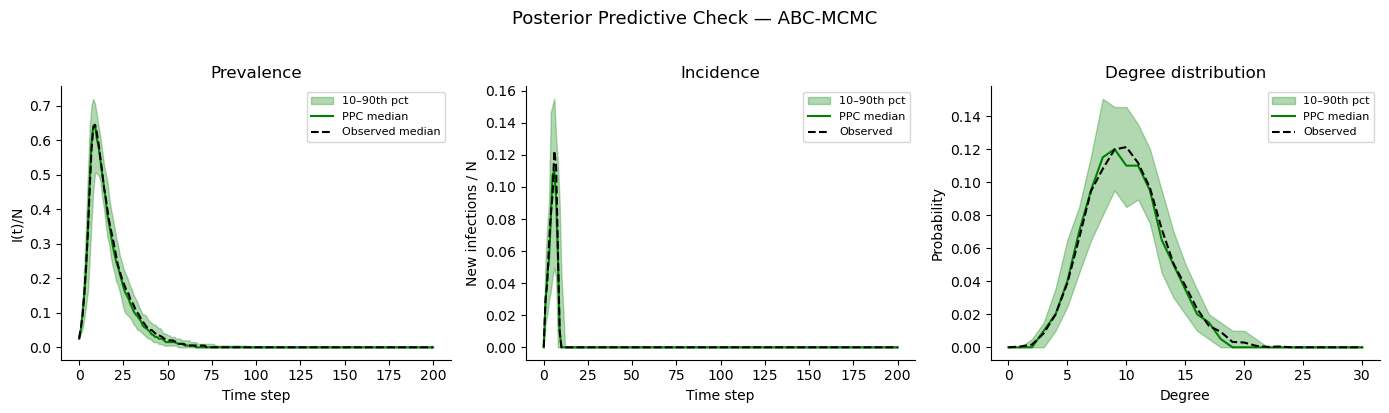

In [27]:
# Posterior predictive check (ABC-MCMC)

rng_ppc_mcmc = np.random.default_rng(42)
N_PPC = 50

idx = rng_ppc_mcmc.choice(len(chain_mcmc_trimmed), size=N_PPC, replace=False)
draws_mcmc = chain_mcmc_trimmed[idx]

prev_sims_mcmc, inc_sims_mcmc, deg_sims_mcmc = [], [], []

for theta in draws_mcmc:
    beta, gamma, rho = theta
    inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng_ppc_mcmc)
    prev = inf
    inc  = np.clip(np.diff(prev, prepend=prev[0]), 0, None)
    prev_sims_mcmc.append(prev)
    inc_sims_mcmc.append(inc)
    deg_norm = deg / deg.sum() if deg.sum() > 0 else deg
    deg_sims_mcmc.append(deg_norm)

prev_sims_mcmc = np.array(prev_sims_mcmc)
inc_sims_mcmc  = np.array(inc_sims_mcmc)

max_deg_mcmc = max(len(d) for d in deg_sims_mcmc)
deg_mat_mcmc = np.zeros((len(deg_sims_mcmc), max_deg_mcmc))
for i, d in enumerate(deg_sims_mcmc):
    deg_mat_mcmc[i, :len(d)] = d

# Observed data
obs_prev_wide   = infected_obs.pivot(index='time', columns='replicate_id', values='infected_fraction')
obs_prev_median = obs_prev_wide.median(axis=1).values
obs_inc         = np.clip(np.diff(obs_prev_median, prepend=obs_prev_median[0]), 0, None)
t               = np.arange(len(obs_prev_median))

deg_wide = degree_obs.pivot(index='degree', columns='replicate_id', values='count')
deg_wide = deg_wide.div(deg_wide.sum(axis=0), axis=1)
obs_deg  = deg_wide.mean(axis=1).values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Prevalence
ax = axes[0]
ax.fill_between(t, np.percentile(prev_sims_mcmc, 10, axis=0),
                   np.percentile(prev_sims_mcmc, 90, axis=0),
                   alpha=0.3, color='green', label="10–90th pct")
ax.plot(t, np.median(prev_sims_mcmc, axis=0), color='green', label="PPC median")
ax.plot(t, obs_prev_median, 'k--', label="Observed median")
ax.set_xlabel("Time step"); ax.set_ylabel("I(t)/N")
ax.set_title("Prevalence"); ax.legend(fontsize=8)

# Panel 2: Incidence
ax = axes[1]
ax.fill_between(t, np.percentile(inc_sims_mcmc, 10, axis=0),
                   np.percentile(inc_sims_mcmc, 90, axis=0),
                   alpha=0.3, color='green', label="10–90th pct")
ax.plot(t, np.median(inc_sims_mcmc, axis=0), color='green', label="PPC median")
ax.plot(t, obs_inc, 'k--', label="Observed")
ax.set_xlabel("Time step"); ax.set_ylabel("New infections / N")
ax.set_title("Incidence"); ax.legend(fontsize=8)

# Panel 3: Degree distribution
ax = axes[2]
deg_x = np.arange(max_deg_mcmc)
ax.fill_between(deg_x, np.percentile(deg_mat_mcmc, 10, axis=0),
                        np.percentile(deg_mat_mcmc, 90, axis=0),
                        alpha=0.3, color='green', label="10–90th pct")
ax.plot(deg_x, np.median(deg_mat_mcmc, axis=0), color='green', label="PPC median")
ax.plot(np.arange(len(obs_deg)), obs_deg, 'k--', label="Observed")
ax.set_xlabel("Degree"); ax.set_ylabel("Probability")
ax.set_title("Degree distribution"); ax.legend(fontsize=8)

sns.despine()
plt.suptitle("Posterior Predictive Check — ABC-MCMC", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("ppc_abc_mcmc.png", dpi=150, bbox_inches='tight')
plt.show()


## Method 5: SMC-ABC

This section adds Toni et al.-style SMC-ABC after rejection ABC. It runs a sequence of decreasing tolerances, then reuses and perturbs previously accepted particles instead of restarting from the prior at every stage. That is usually more simulation-efficient once a rough posterior region has been found.

In [28]:
PARAM_NAMES_SMC = ["beta", "gamma", "rho"]
PRIOR_BOUNDS_SMC = np.array([
    PRIOR_BETA,
    PRIOR_GAMMA,
    PRIOR_RHO,
], dtype=float)

SMC_SUMMARY_IDX = np.array(FINAL_JOINT, dtype=int)
SMC_SUMMARY_NAMES = [SUMMARY_NAMES[i] for i in SMC_SUMMARY_IDX]

def simulate_model(theta, rng):
    beta, gamma, rho = theta
    return simulate(beta=beta, gamma=gamma, rho=rho, rng=rng)

def summary_model(sim_data):
    infected_fraction, rewire_counts, degree_histogram = sim_data
    return calc_summaries(
        infected_fraction,
        rewire_counts,
        degree_histogram
    )[SMC_SUMMARY_IDX]

s_obs_smc = np.asarray(s_obs[SMC_SUMMARY_IDX], dtype=float)

summary_scale = None
if "sims_prior" in globals():
    summary_scale = sims_prior[:, SMC_SUMMARY_IDX].std(axis=0)
    summary_scale = np.where(summary_scale == 0, 1.0, summary_scale)
if summary_scale is None:
    summary_scale = np.ones(len(SMC_SUMMARY_IDX), dtype=float)

print("SMC summary subset:")
print(SMC_SUMMARY_NAMES)
print("Number of summaries:", len(SMC_SUMMARY_IDX))

SMC summary subset:
['early_mass', 'early_rewire', 'slope_growth', 't_10', 't_5', 't_20', 'auc', 'duration_10', 'total_rewire', 'peak', 'rewire_to_auc', 'corr_I_R', 'max_rewire', 'inc_peak', 't_peak', 'corr_dI_R']
Number of summaries: 16


In [29]:
# SMC helpers

def weighted_quantile(x, w, q):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    idx = np.argsort(x)
    x = x[idx]
    w = w[idx]
    cdf = np.cumsum(w) / np.sum(w)
    return np.interp(q, cdf, x)

def log_uniform_prior(theta, bounds):
    theta = np.asarray(theta, dtype=float)
    inside = np.all((theta >= bounds[:, 0]) & (theta <= bounds[:, 1]))
    if not inside:
        return -np.inf
    return -np.sum(np.log(bounds[:, 1] - bounds[:, 0]))

def systematic_resample(weights, rng):
    n = len(weights)
    positions = (rng.random() + np.arange(n)) / n
    cumsum = np.cumsum(weights)
    idx = np.zeros(n, dtype=int)

    i = 0
    j = 0
    while i < n:
        if positions[i] < cumsum[j]:
            idx[i] = j
            i += 1
        else:
            j += 1
    return idx

def sample_from_kernel(prev_particles, prev_weights, cov, rng, max_tries=5000):
    n = len(prev_particles)
    for _ in range(max_tries):
        i = rng.choice(n, p=prev_weights)
        theta = rng.multivariate_normal(prev_particles[i], cov)
        if np.all(theta >= PRIOR_BOUNDS_SMC[:, 0]) and np.all(theta <= PRIOR_BOUNDS_SMC[:, 1]):
            return theta
    return None

def log_mixture_density(theta, prev_particles, prev_weights, cov):
    # Vectorised: evaluate all N kernels at once instead of looping
    log_probs = multivariate_normal.logpdf(
        prev_particles, mean=theta, cov=cov   # shape (N,)
    )
    log_w = np.log(prev_weights + 1e-300)
    vals = log_w + log_probs
    m = np.max(vals)
    return m + np.log(np.sum(np.exp(vals - m)))

In [30]:
def smc_abc_improved(
    n_particles=1000,
    pilot_size=4000,
    max_populations=8,
    init_q=0.50,
    adapt_q=0.50,
    kernel_scale=1.0,
    ess_threshold_frac=0.50,
    min_acceptance=0.005,
    max_tries_per_particle=10000,
    rng=np.random.default_rng(7),
):
    # ---------- pilot from prior ----------
    pilot_thetas = np.zeros((pilot_size, 3))
    pilot_dists = np.zeros(pilot_size)

    for i in range(pilot_size):
        theta = sample_prior(rng)
        sim_data = simulate_model(theta, rng)
        s_sim = summary_model(sim_data)
        d = distance_fn(s_sim, s_obs_smc, scale=summary_scale)
        pilot_thetas[i] = theta
        pilot_dists[i] = d

    eps0 = np.quantile(pilot_dists, init_q)

    keep = pilot_dists <= eps0
    particles0 = pilot_thetas[keep]
    dists0 = pilot_dists[keep]

    while len(particles0) < n_particles:
        theta = sample_prior(rng)
        sim_data = simulate_model(theta, rng)
        s_sim = summary_model(sim_data)
        d = distance_fn(s_sim, s_obs_smc, scale=summary_scale)
        if d <= eps0:
            particles0 = np.vstack([particles0, theta])
            dists0 = np.append(dists0, d)

    particles = [particles0[:n_particles]]
    weights = [np.ones(n_particles) / n_particles]
    distances = [dists0[:n_particles]]

    summaries0 = np.array([
        summary_model(simulate_model(theta, rng))
        for theta in particles[0]
    ])
    summaries = [summaries0]

    acceptance_rates = [float(np.mean(pilot_dists <= eps0))]
    covariances = []
    eps_schedule = [float(eps0)]

    # ---------- sequential populations ----------
    for t in range(1, max_populations):
        prev_particles = particles[-1]
        prev_weights = weights[-1]

        cov_t = kernel_scale * weighted_cov(prev_particles, prev_weights)
        covariances.append(cov_t)

        accepted_particles = []
        accepted_summaries = []
        accepted_distances = []
        logw = []

        tries = 0
        accepts = 0
        eps_t = eps_schedule[-1]

        while len(accepted_particles) < n_particles and tries < n_particles * max_tries_per_particle:
            tries += 1

            theta = sample_from_kernel(prev_particles, prev_weights, cov_t, rng)
            if theta is None:
                continue

            sim_data = simulate_model(theta, rng)
            s_sim = summary_model(sim_data)
            d = distance_fn(s_sim, s_obs_smc, scale=summary_scale)

            if d <= eps_t:
                accepts += 1
                accepted_particles.append(theta)
                accepted_summaries.append(s_sim)
                accepted_distances.append(d)

                log_num = log_uniform_prior(theta, PRIOR_BOUNDS_SMC)
                log_den = log_mixture_density(theta, prev_particles, prev_weights, cov_t)
                logw.append(log_num - log_den)

        if len(accepted_particles) < n_particles:
            print(f"Stopped early at population {t}: insufficient accepted particles.")
            break

        accepted_particles = np.asarray(accepted_particles, dtype=float)
        accepted_summaries = np.asarray(accepted_summaries, dtype=float)
        accepted_distances = np.asarray(accepted_distances, dtype=float)
        logw = np.asarray(logw, dtype=float)

        m = np.max(logw)
        w = np.exp(logw - m)
        w = w / w.sum()

        if ess(w) < ess_threshold_frac * n_particles:
            idx = systematic_resample(w, rng)
            accepted_particles = accepted_particles[idx]
            accepted_summaries = accepted_summaries[idx]
            accepted_distances = accepted_distances[idx]
            w = np.ones(n_particles) / n_particles

        particles.append(accepted_particles)
        weights.append(w)
        distances.append(accepted_distances)
        summaries.append(accepted_summaries)
        acceptance_rates.append(accepts / max(tries, 1))

        next_eps = weighted_quantile(accepted_distances, w, adapt_q)
        if next_eps >= eps_t:
            next_eps = 0.95 * eps_t
        eps_schedule.append(float(next_eps))

        if acceptance_rates[-1] < min_acceptance:
            print(f"Stopped at population {t}: acceptance rate too low.")
            break

    return {
        "particles": particles,
        "weights": weights,
        "distances": distances,
        "summaries": summaries,
        "acceptance_rates": acceptance_rates,
        "covariances": covariances,
        "eps_schedule": eps_schedule,
    }

In [31]:
# Running SMC-ABC

print("Starting SMC-ABC...")
print(f"Max populations: 12, Particles per pop: 1000\n")

print("Initializing ABC-SMC (Pilot Run)...")

smc_result = smc_abc_improved(
    n_particles=1000,
    pilot_size=4000,
    max_populations=12,       
    init_q=0.30,              
    adapt_q=0.40,            
    kernel_scale=1.2,          
    ess_threshold_frac=0.80,   # Resample when ESS < 80%
    min_acceptance=0.010,    
    max_tries_per_particle=15000,
    rng=np.random.default_rng(7),
)

print("\nABC-SMC Completed.")

smc_particles = smc_result["particles"]
smc_weights = smc_result["weights"]
smc_distances = smc_result["distances"]
smc_summaries = smc_result["summaries"]
smc_acceptance_rates = smc_result["acceptance_rates"]
smc_covariances = smc_result["covariances"]
eps_schedule = smc_result["eps_schedule"]

# Summary output
print("\n" + "="*30)
print("SMC-ABC Summary")
print("="*30)
print(f"Total Populations Completed: {len(smc_summaries)}")
print(f"Final Epsilon (Tolerance): {eps_schedule[-1]:.6f}")
print(f"Final Acceptance Rate: {smc_acceptance_rates[-1]:.4f}")
print("-" * 30)
print("Epsilon Schedule:", np.round(eps_schedule, 4).tolist())
print("="*30)

Starting SMC-ABC...
Max populations: 12, Particles per pop: 1000

Initializing ABC-SMC (Pilot Run)...
Stopped at population 11: acceptance rate too low.

ABC-SMC Completed.

SMC-ABC Summary
Total Populations Completed: 12
Final Epsilon (Tolerance): 0.239039
Final Acceptance Rate: 0.0076
------------------------------
Epsilon Schedule: [2.6128, 1.9382, 1.4974, 1.1379, 0.8851, 0.7012, 0.5539, 0.4529, 0.3746, 0.3165, 0.2736, 0.239]


In [32]:
# Extract final population

final_particles = smc_particles[-1]
final_weights = smc_weights[-1]
final_summaries = smc_summaries[-1]
final_distances = smc_distances[-1]

print(f"Final population extracted:")
print(f"  Particles shape: {final_particles.shape}")
print(f"  Weights shape: {final_weights.shape}")
print(f"  Weights sum: {final_weights.sum():.8f}")
print(f"  ESS of final weights: {ess(final_weights):.0f}/{len(final_weights)}")
print(f"  Min distance in final pop: {final_distances.min():.6f}")
print(f"  Max distance in final pop: {final_distances.max():.6f}")
print(f"  Mean distance in final pop: {final_distances.mean():.6f}")

Final population extracted:
  Particles shape: (1000, 3)
  Weights shape: (1000,)
  Weights sum: 1.00000000
  ESS of final weights: 830/1000
  Min distance in final pop: 0.112801
  Max distance in final pop: 0.273555
  Mean distance in final pop: 0.238443


In [33]:
# SMC diagnostics table

smc_diagnostics_df = pd.DataFrame({
    "population": np.arange(len(smc_particles)),
    "epsilon": eps_schedule[:len(smc_particles)],
    "acceptance_rate": smc_acceptance_rates,
    "ess": [ess(w) for w in smc_weights],
    "n_particles": [len(p) for p in smc_particles],
})

display(smc_diagnostics_df)

,population,epsilon,acceptance_rate,ess,n_particles
0,0,2.612822,0.300000,1000.000000,1000
1,1,1.938216,0.551572,880.049190,1000
2,2,1.497362,0.255558,963.054561,1000
3,3,1.137910,0.209732,954.293377,1000
4,4,0.885083,0.177904,958.063846,1000
5,5,0.701235,0.162285,926.793249,1000
6,6,0.553921,0.133280,886.794498,1000
7,7,0.452949,0.091929,868.073937,1000
8,8,0.374580,0.063387,887.594535,1000
9,9,0.316545,0.035144,1000.000000,1000


In [34]:
# SMC-ABC posterior summary and contraction
# Compute weighted mean and weighted standard deviation

smc_wmean = np.average(final_particles, axis=0, weights=final_weights)
smc_wstd  = np.sqrt(np.average(
    (final_particles - smc_wmean)**2, axis=0, weights=final_weights
))

prior_std = np.array([
    (PRIOR_BETA[1]  - PRIOR_BETA[0])  / np.sqrt(12),
    (PRIOR_GAMMA[1] - PRIOR_GAMMA[0]) / np.sqrt(12),
    (PRIOR_RHO[1]   - PRIOR_RHO[0])   / np.sqrt(12),
])

print(f"{'Parameter':<10} {'Prior std':>10} {'SMC mean':>10} {'SMC std':>10} {'Contraction':>12}")
print("-" * 56)
for j, label in enumerate(["beta", "gamma", "rho"]):
    contraction = 1 - smc_wstd[j] / prior_std[j]
    print(f"{label:<10} {prior_std[j]:>10.4f} {smc_wmean[j]:>10.4f} {smc_wstd[j]:>10.4f} {contraction:>11.1%}")

print("\nContraction = 1 - (posterior std / prior std)")
print("Higher % = more information learned from data")

Parameter   Prior std   SMC mean    SMC std  Contraction
--------------------------------------------------------
beta           0.1299     0.1586     0.0186       85.6%
gamma          0.0520     0.0809     0.0060       88.4%
rho            0.2309     0.3082     0.0276       88.1%

Contraction = 1 - (posterior std / prior std)
Higher % = more information learned from data


In [35]:
rng_smc = np.random.default_rng(2026)
n_smc_draws = 2000

smc_idx = rng_smc.choice(
    len(final_particles),
    size=n_smc_draws,
    replace=True,
    p=final_weights
)
smc_draws_joint = final_particles[smc_idx]

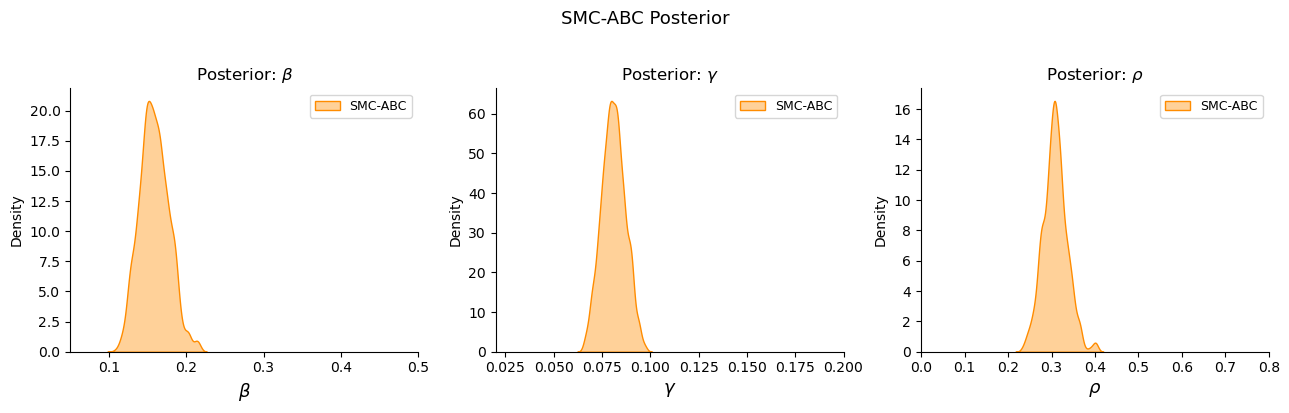

In [36]:
# SMC-ABC marginal posteriors

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(smc_draws_joint[:, j], ax=ax, color="darkorange",
                fill=True, alpha=0.4, label="SMC-ABC", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("SMC-ABC Posterior", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

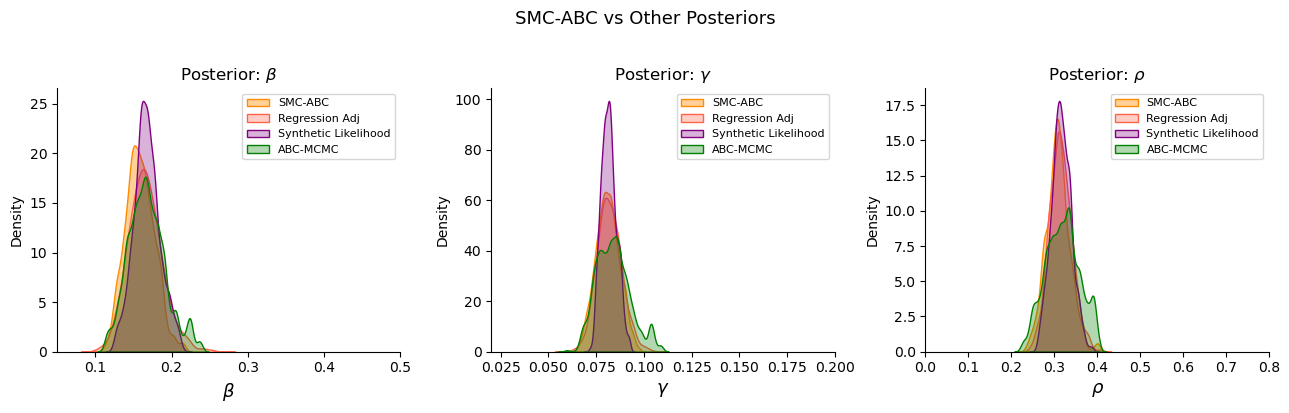


SMC-ABC posterior means:
  beta  = 0.1583 ± 0.0188
  gamma = 0.0808 ± 0.0060
  rho   = 0.3076 ± 0.0276


In [37]:
# SMC-ABC versus other posteriors

PARAM_NAMES  = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
    sns.kdeplot(smc_draws_joint[:, j], ax=ax, color="darkorange",
                fill=True, alpha=0.4, label="SMC-ABC", clip=bounds)
    sns.kdeplot(params_adjusted[:, j], ax=ax, color="tomato",
                fill=True, alpha=0.3, label="Regression Adj", clip=bounds)
    sns.kdeplot(chain_sl_trimmed[:, j], ax=ax, color="purple",
                fill=True, alpha=0.3, label="Synthetic Likelihood", clip=bounds)
    sns.kdeplot(chain_mcmc_trimmed[:, j], ax=ax, color="green",
                fill=True, alpha=0.3, label="ABC-MCMC", clip=bounds)
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Posterior: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("SMC-ABC vs Other Posteriors", y=1.02, fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

print("\nSMC-ABC posterior means:")
print(f"  beta  = {smc_draws_joint[:, 0].mean():.4f} ± {smc_draws_joint[:, 0].std():.4f}")
print(f"  gamma = {smc_draws_joint[:, 1].mean():.4f} ± {smc_draws_joint[:, 1].std():.4f}")
print(f"  rho   = {smc_draws_joint[:, 2].mean():.4f} ± {smc_draws_joint[:, 2].std():.4f}")

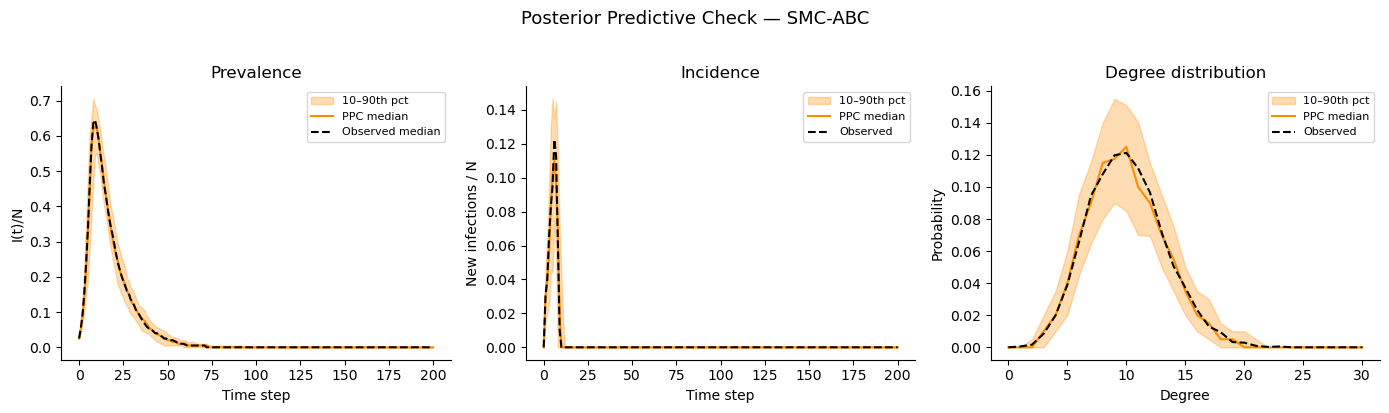

In [38]:
# SMC-ABC posterior predictive check

rng_ppc_smc = np.random.default_rng(42)
N_PPC = 50

idx = rng_ppc_smc.choice(len(final_particles), size=N_PPC, replace=True, p=final_weights)
draws_smc = final_particles[idx]

prev_sims_smc, inc_sims_smc, deg_sims_smc = [], [], []

for theta in draws_smc:
    beta, gamma, rho = theta
    inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng_ppc_smc)
    prev = inf
    inc  = np.clip(np.diff(prev, prepend=prev[0]), 0, None)
    prev_sims_smc.append(prev)
    inc_sims_smc.append(inc)
    deg_norm = deg / deg.sum() if deg.sum() > 0 else deg
    deg_sims_smc.append(deg_norm)

prev_sims_smc = np.array(prev_sims_smc)
inc_sims_smc  = np.array(inc_sims_smc)

max_deg_smc = max(len(d) for d in deg_sims_smc)
deg_mat_smc = np.zeros((len(deg_sims_smc), max_deg_smc))
for i, d in enumerate(deg_sims_smc):
    deg_mat_smc[i, :len(d)] = d

# Observed data
obs_prev_wide   = infected_obs.pivot(index='time', columns='replicate_id', values='infected_fraction')
obs_prev_median = obs_prev_wide.median(axis=1).values
obs_inc         = np.clip(np.diff(obs_prev_median, prepend=obs_prev_median[0]), 0, None)
t               = np.arange(len(obs_prev_median))

deg_wide = degree_obs.pivot(index='degree', columns='replicate_id', values='count')
deg_wide = deg_wide.div(deg_wide.sum(axis=0), axis=1)
obs_deg  = deg_wide.mean(axis=1).values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Prevalence
ax = axes[0]
ax.fill_between(t, np.percentile(prev_sims_smc, 10, axis=0),
                np.percentile(prev_sims_smc, 90, axis=0),
                alpha=0.3, color='darkorange', label='10–90th pct')
ax.plot(t, np.median(prev_sims_smc, axis=0), color='darkorange', label='PPC median')
ax.plot(t, obs_prev_median, 'k--', label='Observed median')
ax.set_xlabel('Time step'); ax.set_ylabel('I(t)/N')
ax.set_title('Prevalence'); ax.legend(fontsize=8)

# Panel 2: Incidence
ax = axes[1]
ax.fill_between(t, np.percentile(inc_sims_smc, 10, axis=0),
                np.percentile(inc_sims_smc, 90, axis=0),
                alpha=0.3, color='darkorange', label='10–90th pct')
ax.plot(t, np.median(inc_sims_smc, axis=0), color='darkorange', label='PPC median')
ax.plot(t, obs_inc, 'k--', label='Observed')
ax.set_xlabel('Time step'); ax.set_ylabel('New infections / N')
ax.set_title('Incidence'); ax.legend(fontsize=8)

# Panel 3: Degree distribution
ax = axes[2]
deg_x = np.arange(max_deg_smc)
ax.fill_between(deg_x, np.percentile(deg_mat_smc, 10, axis=0),
                        np.percentile(deg_mat_smc, 90, axis=0),
                        alpha=0.3, color='darkorange', label='10–90th pct')
ax.plot(deg_x, np.median(deg_mat_smc, axis=0), color='darkorange', label='PPC median')
ax.plot(np.arange(len(obs_deg)), obs_deg, 'k--', label='Observed')
ax.set_xlabel('Degree'); ax.set_ylabel('Probability')
ax.set_title('Degree distribution'); ax.legend(fontsize=8)

sns.despine()
plt.suptitle('Posterior Predictive Check — SMC-ABC', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('ppc_smc_abc.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Posterior predictive summary verification

rng_ppc = np.random.default_rng(2027)
n_ppc = 200

ppc_idx = rng_ppc.choice(
    len(final_particles),
    size=n_ppc,
    replace=True,
    p=final_weights
)
ppc_thetas = final_particles[ppc_idx]

ppc_summaries = np.array([
    summary_model(simulate_model(theta, rng_ppc))
    for theta in ppc_thetas
])

ppc_mean = ppc_summaries.mean(axis=0)
ppc_lo = np.quantile(ppc_summaries, 0.10, axis=0)
ppc_hi = np.quantile(ppc_summaries, 0.90, axis=0)

smc_summary_check = pd.DataFrame({
    "summary": SMC_SUMMARY_NAMES,
    "observed": s_obs_smc,
    "pp_mean": ppc_mean,
    "pp_q10": ppc_lo,
    "pp_q90": ppc_hi,
    "inside_80pct_band": (s_obs_smc >= ppc_lo) & (s_obs_smc <= ppc_hi),
})

display(smc_summary_check)

,summary,observed,pp_mean,pp_q10,pp_q90,inside_80pct_band
0,early_mass,10.728000,10.748575,9.549000,12.234500,True
1,early_rewire,545.150000,544.645000,465.800000,613.100000,True
2,slope_growth,-0.031805,-0.032765,-0.050083,-0.016589,True
3,t_10,2.575000,2.570000,2.000000,3.100000,True
4,t_5,1.225000,1.270000,1.000000,2.000000,True
5,t_20,4.075000,4.075000,3.000000,5.000000,True
6,auc,11.399000,11.446500,9.912000,13.150000,True
7,duration_10,31.175000,30.805000,27.000000,35.000000,True
8,total_rewire,545.150000,544.645000,465.800000,613.100000,True
9,peak,0.657125,0.662900,0.590000,0.730000,True


## Synthetic Truth Recovery Experiment

True parameters:
  beta*  = 0.20
  gamma* = 0.10
  rho*   = 0.35

Simulated 40 replicates from true parameters.
Synthetic observed summaries computed.

Rejection ABC results:
  Threshold distance: 0.9916
  Number accepted:    2001

Parameter    True   ABC mean   ABC std  ABC ok?   Reg mean   Reg std  Reg ok?
----------------------------------------------------------------------
  beta        0.200     0.2251    0.0542    YES ✓     0.2085    0.0275    YES ✓
  gamma       0.100     0.1081    0.0180    YES ✓     0.1022    0.0076    YES ✓
  rho         0.350     0.3675    0.0748    YES ✓     0.3541    0.0286    YES ✓


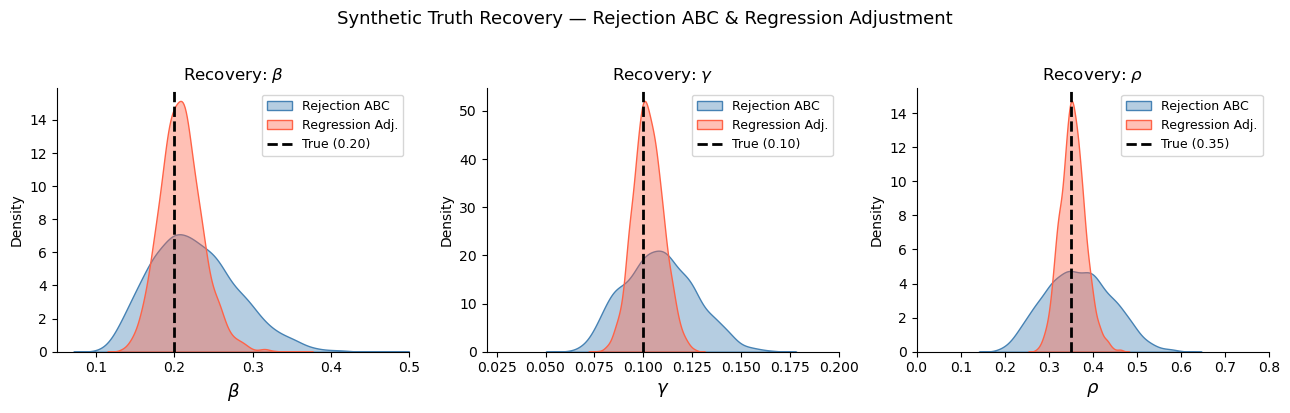

In [40]:
# ── Synthetic Truth Recovery Experiment ──────────────────────────────────────
# Use known true parameters and simulate synthetic data
# Evaluate recovery under rejection ABC and regression adjustment

# ── Step 1: Choose true parameters ──
theta_true = np.array([0.20, 0.10, 0.35])  # beta*, gamma*, rho*
print("True parameters:")
print(f"  beta*  = {theta_true[0]:.2f}")
print(f"  gamma* = {theta_true[1]:.2f}")
print(f"  rho*   = {theta_true[2]:.2f}")

# ── Step 2: Simulate R=40 replicates from true parameters ──
R = 40
rng_truth = np.random.default_rng(2027)

inf_list, rew_list, deg_list = [], [], []
for _ in range(R):
    inf, rew, deg = simulate(beta=theta_true[0], gamma=theta_true[1],
                             rho=theta_true[2], rng=rng_truth)
    inf_list.append(inf)
    rew_list.append(rew)
    deg_list.append(deg)

print(f"\nSimulated {R} replicates from true parameters.")

# ── Step 3: Compute observed summaries from synthetic data ──
synth_summaries = []
for i in range(R):
    s = calc_summaries(inf_list[i], rew_list[i], deg_list[i])
    synth_summaries.append(s)

synth_summaries = np.array(synth_summaries)
s_synth = synth_summaries.mean(axis=0)
s_synth_norm = s_synth / s_std
print("Synthetic observed summaries computed.")

# ── Step 4: Run rejection ABC at 2% acceptance rate ──
params_synth, mask_synth, threshold_synth = abc_rejection(
    s_synth_norm, sims_norm, params_prior,
    stat_indices=FINAL_JOINT,
    acceptance_rate=0.02       # Match baseline pipeline
)
sims_synth_accepted = sims_prior[mask_synth]

print(f"\nRejection ABC results:")
print(f"  Threshold distance: {threshold_synth:.4f}")
print(f"  Number accepted:    {len(params_synth)}")

# ── Step 5: Apply regression adjustment on synthetic ABC samples ──
params_synth_adjusted = regression_adjustment(
    params_synth, sims_synth_accepted, s_synth, FINAL_JOINT
)

# ── Step 6: Print coverage table for both methods ──
print(f"\n{'Parameter':<10} {'True':>6} {'ABC mean':>10} {'ABC std':>9} {'ABC ok?':>8} {'Reg mean':>10} {'Reg std':>9} {'Reg ok?':>8}")
print("-" * 70)
for j, (name, true_val) in enumerate(zip(['beta', 'gamma', 'rho'], theta_true)):
    abc_mean = params_synth[:, j].mean()
    abc_std  = params_synth[:, j].std()
    reg_mean = params_synth_adjusted[:, j].mean()
    reg_std  = params_synth_adjusted[:, j].std()
    abc_ok   = abs(abc_mean - true_val) <= 2 * abc_std
    reg_ok   = abs(reg_mean - true_val) <= 2 * reg_std
    print(f"  {name:<10} {true_val:>6.3f} {abc_mean:>10.4f} {abc_std:>9.4f} {'YES ✓' if abc_ok else 'NO ✗':>8} {reg_mean:>10.4f} {reg_std:>9.4f} {'YES ✓' if reg_ok else 'NO ✗':>8}")

# ── Step 7: Plot posteriors vs true values ──
PARAM_NAMES  = [r"$\beta$", r"$\gamma$", r"$\rho$"]
PRIOR_BOUNDS = [PRIOR_BETA, PRIOR_GAMMA, PRIOR_RHO]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for j, (ax, name, bounds, true_val) in enumerate(
        zip(axes, PARAM_NAMES, PRIOR_BOUNDS, theta_true)):
    # Rejection ABC posterior
    sns.kdeplot(params_synth[:, j], ax=ax, color='steelblue',
                fill=True, alpha=0.4, label="Rejection ABC", clip=bounds)
    # Regression adjustment posterior
    sns.kdeplot(params_synth_adjusted[:, j], ax=ax, color='tomato',
                fill=True, alpha=0.4, label="Regression Adj.", clip=bounds)
    # True value
    ax.axvline(true_val, color='black', linewidth=2,
               linestyle='--', label=f"True ({true_val:.2f})")
    ax.set_xlabel(name, fontsize=13)
    ax.set_xlim(bounds)
    ax.set_title(f"Recovery: {name}")
    if j == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=9)

sns.despine()
plt.suptitle("Synthetic Truth Recovery — Rejection ABC & Regression Adjustment",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("synthetic_truth_recovery.png", dpi=150, bbox_inches='tight')
plt.show()



## Final Section: All Methods Comparison (Including SMC)

This final section compares **Regression Adjustment**, **Random Forest**, **Synthetic Likelihood**, **ABC-MCMC**, and **SMC-ABC** using comparable posterior samples and parameter uncertainty metrics.

5-method parameter metrics:


,Method,beta_mean,beta_std,gamma_mean,gamma_std,rho_mean,rho_std,avg_contraction_%
0,Synthetic Likelihood,0.1671,0.0169,0.0815,0.0040,0.3157,0.0228,89.8290
1,Random Forest,0.1606,0.0192,0.0798,0.0052,0.2967,0.0276,87.7437
2,SMC-ABC,0.1586,0.0188,0.0808,0.0061,0.3082,0.0274,87.3390
3,Regression Adj,0.1652,0.0228,0.0818,0.0065,0.3140,0.0263,86.1466
4,ABC-MCMC,0.1673,0.0244,0.0837,0.0089,0.3188,0.0395,82.3374


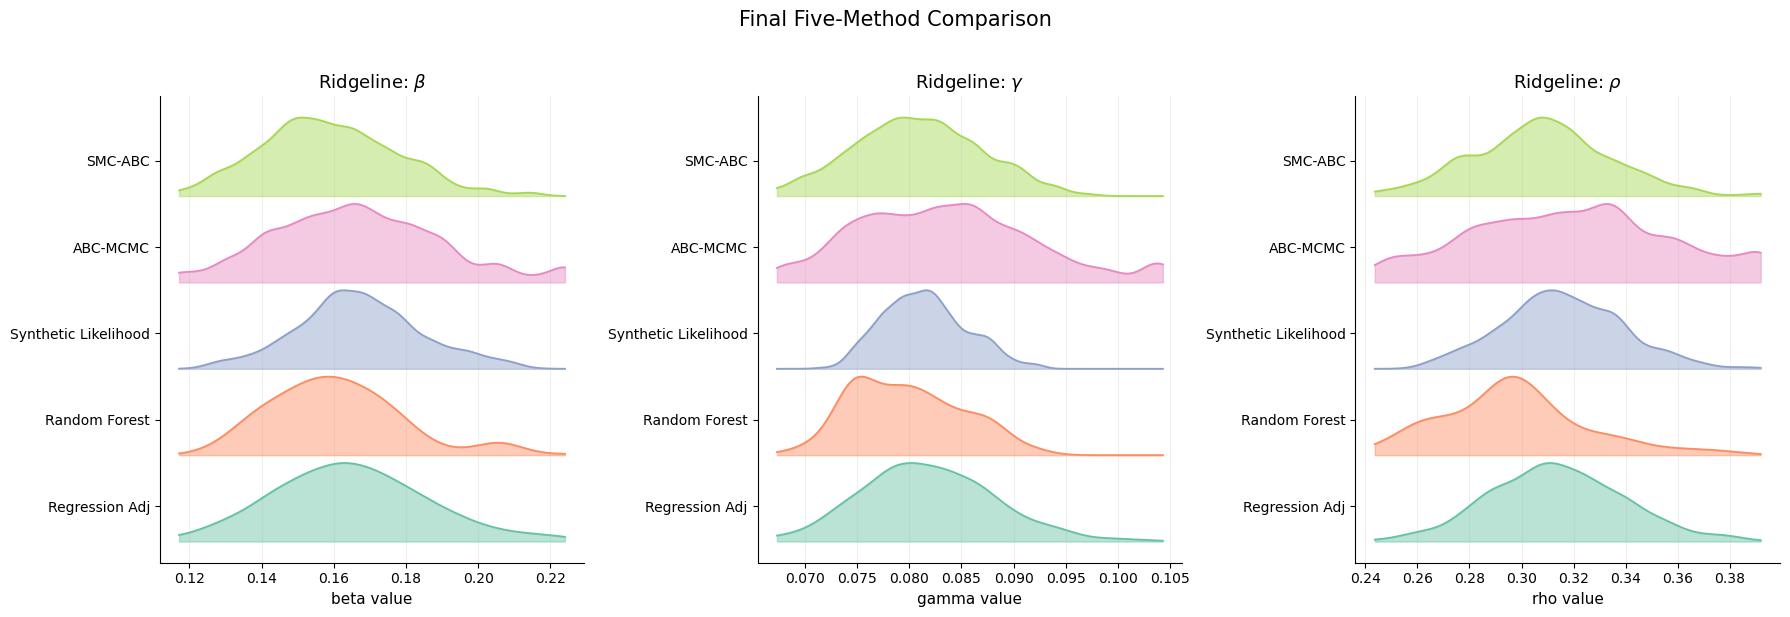

In [41]:
# Build comparable posterior samples for five methods
rng_compare = np.random.default_rng(2026)

# Random forest uncertainty proxy from tree-level predictions
rf_beta_trees = np.array([est.predict(s_obs.reshape(1, -1))[0] for est in rf_beta.estimators_], dtype=float)
rf_gamma_trees = np.array([est.predict(s_obs.reshape(1, -1))[0] for est in rf_gamma.estimators_], dtype=float)
rf_rho_trees = np.array([est.predict(s_obs.reshape(1, -1))[0] for est in rf_rho.estimators_], dtype=float)
rf_samples = np.column_stack([rf_beta_trees, rf_gamma_trees, rf_rho_trees])

# Weighted SMC resampling for comparability
n_smc_draws = 4000
smc_draw_idx = rng_compare.choice(len(final_particles), size=n_smc_draws, replace=True, p=final_weights)
smc_draws = final_particles[smc_draw_idx]

method_samples = {
    "Regression Adj": np.asarray(params_adjusted, dtype=float),
    "Random Forest": rf_samples,
    "Synthetic Likelihood": np.asarray(chain_sl_trimmed, dtype=float),
    "ABC-MCMC": np.asarray(chain_mcmc_trimmed, dtype=float),
    "SMC-ABC": np.asarray(smc_draws, dtype=float),
}

labels = ["beta", "gamma", "rho"]
prior_std_map = dict(zip(labels, prior_std))

# Compute metrics table
metrics_rows = []
for method, samples in method_samples.items():
    means = samples.mean(axis=0)
    stds = samples.std(axis=0, ddof=1)
    contractions = [1 - stds[j] / prior_std_map[labels[j]] for j in range(3)]

    metrics_rows.append({
        "Method": method,
        "beta_mean": means[0], "beta_std": stds[0],
        "gamma_mean": means[1], "gamma_std": stds[1],
        "rho_mean": means[2], "rho_std": stds[2],
        "avg_contraction_%": 100 * np.mean(contractions),
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df.sort_values("avg_contraction_%", ascending=False).reset_index(drop=True)

pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
print("5-method parameter metrics:")
display(metrics_df)

# Compare beta, gamma, and rho across five methods
method_order = ["Regression Adj", "Random Forest", "Synthetic Likelihood", "ABC-MCMC", "SMC-ABC"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
palette = sns.color_palette("Set2", n_colors=len(method_order))
param_symbols = [r"$\beta$", r"$\gamma$", r"$\rho$"]

for j, ax in enumerate(axes):
    all_vals = np.concatenate([method_samples[m][:, j] for m in method_order])
    x_min, x_max = np.quantile(all_vals, 0.01), np.quantile(all_vals, 0.99)

    for k, method in enumerate(method_order):
        vals = method_samples[method][:, j]
        kde = gaussian_kde(vals)
        x = np.linspace(x_min, x_max, 300)
        y = kde(x)
        y = y / (y.max() + 1e-12)
        offset = k * 1.1

        ax.fill_between(x, offset, offset + y, alpha=0.45, color=palette[k])
        ax.plot(x, offset + y, color=palette[k], linewidth=1.3)

    ax.set_yticks(np.arange(len(method_order)) * 1.1 + 0.45)
    ax.set_yticklabels(method_order, fontsize=10)
    ax.set_title(f"Ridgeline: {param_symbols[j]}", fontsize=13)
    ax.set_xlabel(f"{labels[j]} value", fontsize=11)
    ax.grid(axis="x", alpha=0.2)
    sns.despine(ax=ax, left=False)

fig.suptitle("Final Five-Method Comparison", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

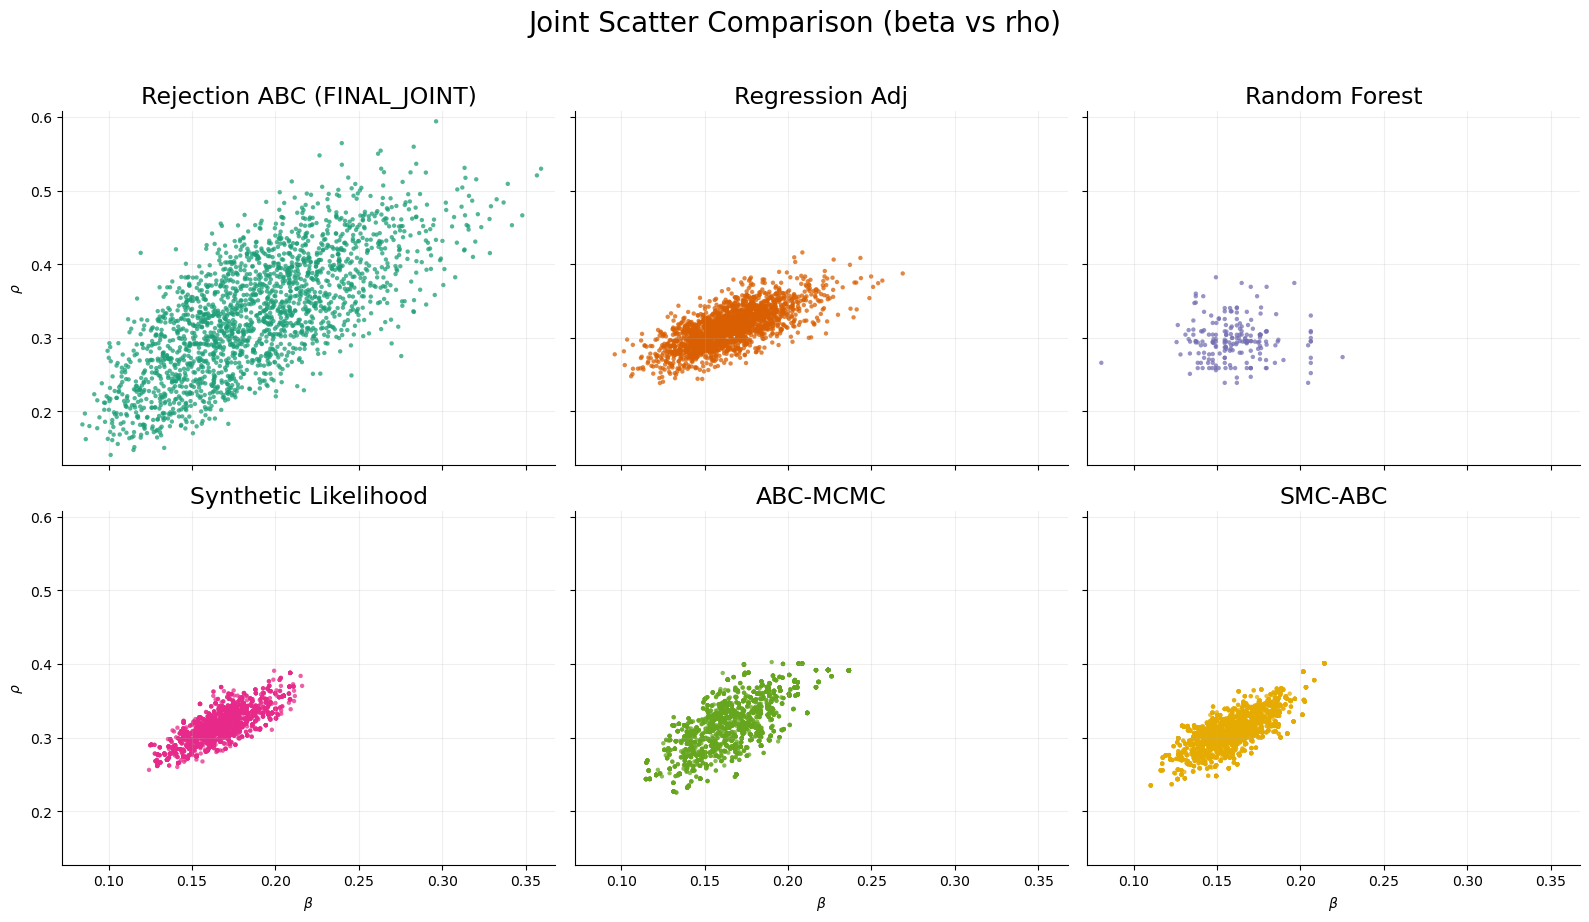

In [42]:
# Joint posterior comparison (beta vs rho)

joint_method_samples = {
    "Rejection ABC (FINAL_JOINT)": np.asarray(params_accepted, dtype=float),
    "Regression Adj": np.asarray(params_adjusted, dtype=float),
    "Random Forest": np.asarray(rf_samples, dtype=float),
    "Synthetic Likelihood": np.asarray(chain_sl_trimmed, dtype=float),
    "ABC-MCMC": np.asarray(chain_mcmc_trimmed, dtype=float),
    "SMC-ABC": np.asarray(smc_draws, dtype=float),
}

joint_order = [
    "Rejection ABC (FINAL_JOINT)",
    "Regression Adj",
    "Random Forest",
    "Synthetic Likelihood",
    "ABC-MCMC",
    "SMC-ABC",
]

i_beta, i_rho = 0, 2

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.ravel()
palette = sns.color_palette("Dark2", n_colors=len(joint_order))

all_beta = np.concatenate([joint_method_samples[m][:, i_beta] for m in joint_order])
all_rho = np.concatenate([joint_method_samples[m][:, i_rho] for m in joint_order])

x_pad = 0.03 * (all_beta.max() - all_beta.min() + 1e-12)
y_pad = 0.03 * (all_rho.max() - all_rho.min() + 1e-12)
xlim = (all_beta.min() - x_pad, all_beta.max() + x_pad)
ylim = (all_rho.min() - y_pad, all_rho.max() + y_pad)

rng_plot = np.random.default_rng(2026)

for k, method in enumerate(joint_order):
    ax = axes[k]
    samp = joint_method_samples[method]

    # Subsample for responsiveness
    n_plot = min(len(samp), 3000)
    idx = rng_plot.choice(len(samp), size=n_plot, replace=False)
    x = samp[idx, i_beta]
    y = samp[idx, i_rho]

    ax.scatter(x, y, s=10, alpha=0.75, color=palette[k], edgecolors="none")
    ax.set_title(method, fontsize=17)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(alpha=0.2)

for i, ax in enumerate(axes):
    if i // 3 == 1:
        ax.set_xlabel(r"$\beta$")
    if i % 3 == 0:
        ax.set_ylabel(r"$\rho$")

sns.despine()
plt.suptitle("Joint Scatter Comparison (beta vs rho)", y=1.02, fontsize=20)
plt.tight_layout()
plt.show()

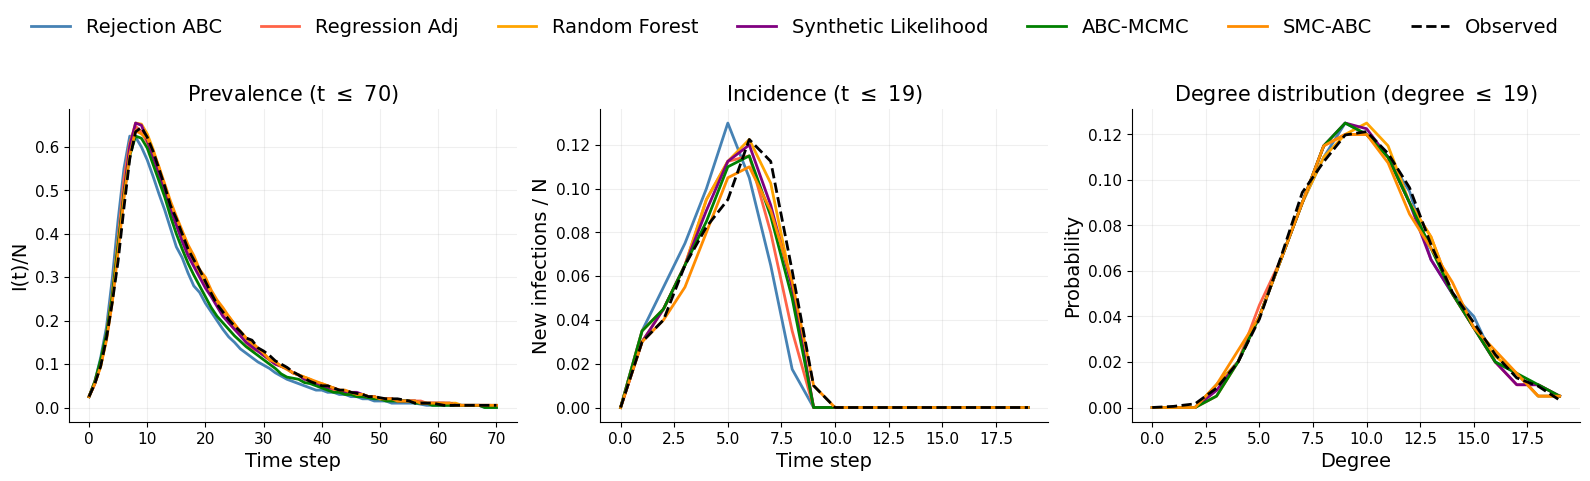

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Prevalence zoomed ---
ax = axes[0]
for method_name, color in method_specs:
    ax.plot(t[:prev_zoom_end + 1], method_medians[method_name]["prev"][:prev_zoom_end + 1],
            color=color, linewidth=2.0, label=method_name)
ax.plot(t[:prev_zoom_end + 1], obs_prev_median[:prev_zoom_end + 1], "k--", linewidth=2.0, label="Observed")
ax.set_title(f"Prevalence (t $\\leq$ {prev_zoom_end})", fontsize=15)
ax.set_xlabel("Time step", fontsize=14)
ax.set_ylabel("I(t)/N", fontsize=14)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.2)

# --- Incidence zoomed ---
ax = axes[1]
for method_name, color in method_specs:
    ax.plot(t[:inc_zoom_end + 1], method_medians[method_name]["inc"][:inc_zoom_end + 1],
            color=color, linewidth=2.0)
ax.plot(t[:inc_zoom_end + 1], obs_inc[:inc_zoom_end + 1], "k--", linewidth=2.0)
ax.set_title(f"Incidence (t $\\leq$ {inc_zoom_end})", fontsize=15)
ax.set_xlabel("Time step", fontsize=14)
ax.set_ylabel("New infections / N", fontsize=14)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.2)

# --- Degree distribution zoomed ---
ax = axes[2]
for method_name, color in method_specs:
    y = method_medians[method_name]["deg"]
    this_end = min(deg_zoom_end + 1, len(y))
    ax.plot(np.arange(this_end), y[:this_end], color=color, linewidth=2.0)
obs_end = min(deg_zoom_end + 1, len(obs_deg))
ax.plot(np.arange(obs_end), obs_deg[:obs_end], "k--", linewidth=2.0)
ax.set_title(f"Degree distribution (degree $\\leq$ {deg_zoom_end})", fontsize=15)
ax.set_xlabel("Degree", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.2)

# Shared legend above
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=7, frameon=False,
           bbox_to_anchor=(0.5, 1.08), fontsize=14)

sns.despine()
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("ppc_zoomed_row.png", dpi=160, bbox_inches="tight")
plt.show()